<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/norwegian_ncs_gas_network_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operating and optimizing the Norwegian rich- and dry-gas value chain with NeqSim

**Scope.** This engineering study builds a large, transparent model of representative
Norwegian Continental Shelf (NCS) rich-gas gathering systems, onshore processing at
Kårstø, Kollsnes, and Nyhamna, the Area D dry-gas export system, and a future
Polarled/Nyhamna tie-in. It uses:

- NeqSim SRK thermodynamics, PT phase envelopes, dew-point flashes, and ISO 6976;
- `PipeBeggsAndBrills` for rich- and dry-gas pipeline hydraulics;
- `LoopedPipeNetwork` for an explicit Kollsnes–Sleipner–Draupner loop;
- assumed, component-by-component NGL recovery factors;
- linear optimization of field rates and export-terminal nominations;
- 2026 Gassco Terms and Conditions as the contractual quality source;
- Norwegian Offshore Directorate (SODIR) sales data as the system-rate benchmark.

**Important boundary.** Public sources generally do not publish field-by-field feed
analyses, booked capacities, compressor maps, nominations, commercial prices, or
recovery guarantees. Field compositions, plant recoveries, availability, costs, and
future rates below are therefore explicitly labelled **representative assumptions**.
They are not operator data and must not be used for nominations, custody transfer,
process guarantees, MAOP verification, or investment approval.

The phrase “Norwegian continental shale” is interpreted here as **Norwegian Continental
Shelf**.

## Executive questions

The notebook answers six practical questions.

1. Which quality limit applies at each rich-gas entry, dry-gas entry, and export exit?
2. How do representative field compositions affect cricondenbar, cricondentherm,
   hydrocarbon dew point, water dew point, GCV, Wobbe index, and CO₂?
3. How much dry gas and NGL result from transparent onshore recovery assumptions?
4. Which long export pipelines become pressure-limited under Beggs–Brill screening?
5. Can the looped NeqSim network solver distribute flow through alternative paths?
6. What field and terminal allocation maximizes an illustrative daily value while
   matching reported NCS sales and respecting plant, quality, and hydraulic constraints?

The calculation chain is:

$$\begin{aligned}
\text{field fluids}
&\rightarrow \text{rich-gas pipelines}
\rightarrow \text{processing and NGL}\\
&\rightarrow \text{dry-gas blending}
\rightarrow \text{Area D network}
\rightarrow \text{export terminals}.
\end{aligned}$$

In [1]:
import importlib.metadata
import subprocess
import sys
import warnings

try:
    import neqsim
    if importlib.metadata.version("neqsim") != "3.16.0":
        raise ImportError("This study is pinned to NeqSim 3.16.0")
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "neqsim==3.16.0"],
        check=True,
    )
    import neqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display
from neqsim import jneqsim
from neqsim.standards import ISO6976
from neqsim.thermo import TPflash, fluid
from scipy.optimize import linprog

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

NEQSIM_VERSION = importlib.metadata.version("neqsim")
print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {sys.version.split()[0]}")
assert NEQSIM_VERSION == "3.16.0"

NeqSim version: 3.16.0
Python version: 3.12.13


## 1. Sources, date, and evidence hierarchy

**Source date:** 29 July 2026. The current contractual documents used here are valid from
1 January 2026.

Contractual limits are transcribed from the applicable Gassco appendices. Asset geometry,
plant capacity, and route descriptions come from Gassco asset pages. Production is checked
against SODIR. A public route or field page does **not** make the synthetic composition an
actual assay.

In [2]:
sources = pd.DataFrame(
    [
        ("Gassled T&C 2026", "quality, pressure, areas, exits", "https://gassco.eu/wp-content/uploads/2026/01/Gassled-Terms-and-Conditions-01.01.2026-with-Appendices.pdf"),
        ("Nyhamna T&C 2026", "Ormen Lange, Polarled, dry exit", "https://gassco.eu/wp-content/uploads/2026/01/Nyhamna-Terms-and-Conditions-01.01.2026-with-Appendices.pdf"),
        ("Polarled T&C 2026", "Polarled entry and Nyhamna exit", "https://gassco.eu/wp-content/uploads/2026/01/Polarled-Terms-and-Conditions-01.01.2026-with-Appendices.pdf"),
        ("Gassco transport map", "pipeline route, length, diameter", "https://gassco.eu/en/transport-map/"),
        ("Gassco Kårstø", "products and product capacities", "https://gassco.eu/en/prosessanlegg/karsto/"),
        ("Gassco Kollsnes", "fields and 144.5 MSm3/d capacity", "https://gassco.eu/en/prosessanlegg/kollsnes/"),
        ("Gassco Nyhamna", "fields and 84 MSm3/d capacity", "https://gassco.eu/en/prosessanlegg/nyhamna/"),
        ("Gassco booking", "capacity, nominations, physical routing", "https://gassco.eu/en/shippers/capacity-booking-and-reporting/"),
        ("Gassco tariffs", "2026 tariff elements", "https://gassco.eu/en/shippers/tariffs-and-areas/"),
        ("SODIR June 2026", "10.0 GSm3 gas sales in June", "https://www.sodir.no/en/whats-new/news/production-figures/2026/production-figures-june-2026/"),
        ("Norwegian petroleum forecast", "2025 gas sales: 121.8 GSm3", "https://www.norskpetroleum.no/en/production-and-exports/production-forecasts/"),
        ("NeqSim network source", "LoopedPipeNetwork API", "https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/network/LoopedPipeNetwork.java"),
        ("NeqSim issue #2656", "unused global Beggs-Brill selector", "https://github.com/equinor/neqsim/issues/2656"),
        ("NeqSim issue #2657", "network roughness unit conversion", "https://github.com/equinor/neqsim/issues/2657"),
    ],
    columns=["source", "used for", "URL"],
)
display(sources)

,source,used for,URL
0,Gassled T&C 2026,"quality, pressure, areas, exits",https://gassco.eu/wp-content/uploads/2026/01/G...
1,Nyhamna T&C 2026,"Ormen Lange, Polarled, dry exit",https://gassco.eu/wp-content/uploads/2026/01/N...
2,Polarled T&C 2026,Polarled entry and Nyhamna exit,https://gassco.eu/wp-content/uploads/2026/01/P...
3,Gassco transport map,"pipeline route, length, diameter",https://gassco.eu/en/transport-map/
4,Gassco Kårstø,products and product capacities,https://gassco.eu/en/prosessanlegg/karsto/
5,Gassco Kollsnes,fields and 144.5 MSm3/d capacity,https://gassco.eu/en/prosessanlegg/kollsnes/
6,Gassco Nyhamna,fields and 84 MSm3/d capacity,https://gassco.eu/en/prosessanlegg/nyhamna/
7,Gassco booking,"capacity, nominations, physical routing",https://gassco.eu/en/shippers/capacity-booking...
8,Gassco tariffs,2026 tariff elements,https://gassco.eu/en/shippers/tariffs-and-areas/
9,SODIR June 2026,10.0 GSm3 gas sales in June,https://www.sodir.no/en/whats-new/news/product...


## 2. Physical and commercial topology

Gassco reports approximately 8,600 km of offshore gas pipelines. The model retains the
essential distinction between:

- **rich-gas areas** A, B, G, H, I, and O;
- **processing areas** C (Kårstø), E (Kollsnes), and P (Nyhamna);
- **dry-gas Area D**, including offshore hubs and export terminals.

A shipper books entry, processing/quality service, and exit capacity; the 2026 Booking
Manual states that the shipper does not choose the physical route. The optimization is
therefore a planning and system-operation example, not a shipper routing instruction.

In [3]:
pipeline_register = pd.DataFrame(
    [
        ("Statpipe rich leg", "Statfjord area", "Kårstø", 228, 28, "rich"),
        ("Åsgard Transport", "Åsgard ESB", "Kårstø", 720, 42, "rich"),
        ("Norne Gas Transport", "Norne", "Åsgard Transport", 128, 16, "rich"),
        ("Kvitebjørn Gas Pipeline", "Kvitebjørn", "Kollsnes", 148, 30, "rich"),
        ("Gjøa–FLAGS", "Gjøa", "FLAGS", 131, 28, "rich/treated"),
        ("Polarled", "Aasta Hansteen", "Nyhamna", 482, 36, "rich"),
        ("Statpipe dry leg", "Kårstø", "Draupner", 203, 36, "dry"),
        ("Zeepipe IIA", "Kollsnes", "Sleipner", 299, 40, "dry"),
        ("Zeepipe IIB", "Kollsnes", "Draupner", 300, 40, "dry"),
        ("Langeled North", "Nyhamna", "Sleipner", 628, 42, "dry"),
        ("Zeepipe interconnector", "Sleipner", "Draupner", 39, 40, "dry"),
        ("Europipe I", "Draupner", "Dornum", 667, 40, "dry"),
        ("Europipe II", "Kårstø", "Dornum", 660, 42, "dry"),
        ("Franpipe", "Draupner", "Dunkerque", 840, 42, "dry"),
        ("Zeepipe trunk", "Sleipner/Draupner", "Zeebrugge", 808, 40, "dry"),
        ("Langeled South", "Sleipner", "Easington", 543, 44, "dry"),
        ("Norpipe", "Ekofisk", "Emden", 440, 36, "dry"),
        ("Vesterled", "Heimdal area", "St Fergus", 361, 32, "dry"),
    ],
    columns=["pipeline", "from", "to", "length_km", "diameter_in", "service"],
)
display(pipeline_register)

,pipeline,from,to,length_km,diameter_in,service
0,Statpipe rich leg,Statfjord area,Kårstø,228,28,rich
1,Åsgard Transport,Åsgard ESB,Kårstø,720,42,rich
2,Norne Gas Transport,Norne,Åsgard Transport,128,16,rich
3,Kvitebjørn Gas Pipeline,Kvitebjørn,Kollsnes,148,30,rich
4,Gjøa–FLAGS,Gjøa,FLAGS,131,28,rich/treated
5,Polarled,Aasta Hansteen,Nyhamna,482,36,rich
6,Statpipe dry leg,Kårstø,Draupner,203,36,dry
7,Zeepipe IIA,Kollsnes,Sleipner,299,40,dry
8,Zeepipe IIB,Kollsnes,Draupner,300,40,dry
9,Langeled North,Nyhamna,Sleipner,628,42,dry


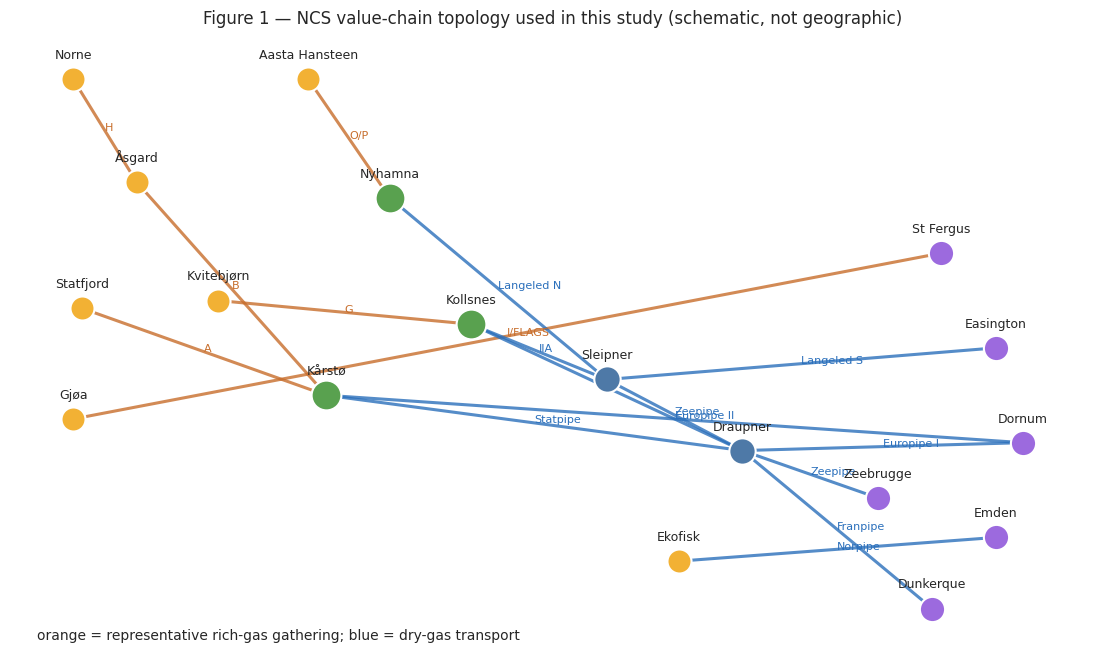

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))
pos = {
    "Norne": (0.5, 7.2), "Aasta Hansteen": (3.1, 7.2), "Åsgard": (1.2, 5.9),
    "Nyhamna": (4.0, 5.7), "Statfjord": (0.6, 4.3), "Kvitebjørn": (2.1, 4.4),
    "Gjøa": (0.5, 2.9), "Kårstø": (3.3, 3.2), "Kollsnes": (4.9, 4.1),
    "Sleipner": (6.4, 3.4), "Draupner": (7.9, 2.5), "Ekofisk": (7.2, 1.1),
    "St Fergus": (10.1, 5.0), "Easington": (10.7, 3.8), "Dornum": (11.0, 2.6),
    "Emden": (10.7, 1.4), "Dunkerque": (10.0, 0.5), "Zeebrugge": (9.4, 1.9),
}
edges = [
    ("Norne", "Åsgard", "H"), ("Åsgard", "Kårstø", "B"), ("Statfjord", "Kårstø", "A"),
    ("Kvitebjørn", "Kollsnes", "G"), ("Gjøa", "St Fergus", "I/FLAGS"),
    ("Aasta Hansteen", "Nyhamna", "O/P"), ("Nyhamna", "Sleipner", "Langeled N"),
    ("Kårstø", "Draupner", "Statpipe"), ("Kårstø", "Dornum", "Europipe II"),
    ("Kollsnes", "Sleipner", "IIA"), ("Kollsnes", "Draupner", "IIB"),
    ("Sleipner", "Draupner", "Zeepipe"), ("Sleipner", "Easington", "Langeled S"),
    ("Draupner", "Dornum", "Europipe I"), ("Draupner", "Dunkerque", "Franpipe"),
    ("Draupner", "Zeebrugge", "Zeepipe"), ("Ekofisk", "Emden", "Norpipe"),
]
for a, b, label in edges:
    x = [pos[a][0], pos[b][0]]
    y = [pos[a][1], pos[b][1]]
    color = "#c76d2b" if label in {"A", "B", "G", "H", "I/FLAGS", "O/P"} else "#2a6fbb"
    ax.plot(x, y, color=color, lw=2.2, alpha=0.8)
    ax.text(np.mean(x), np.mean(y), label, fontsize=8, color=color)
plants = {"Kårstø", "Kollsnes", "Nyhamna"}
hubs = {"Sleipner", "Draupner"}
terminals = {"St Fergus", "Easington", "Dornum", "Emden", "Dunkerque", "Zeebrugge"}
for name, (x, y) in pos.items():
    if name in plants:
        fc, size = "#59a14f", 460
    elif name in terminals:
        fc, size = "#9c6ade", 330
    elif name in hubs:
        fc, size = "#4e79a7", 360
    else:
        fc, size = "#f2b134", 300
    ax.scatter(x, y, s=size, color=fc, edgecolor="white", linewidth=1.5, zorder=3)
    ax.text(x, y + 0.22, name, ha="center", va="bottom", fontsize=9)
ax.text(
    0.1,
    0.1,
    "orange = representative rich-gas gathering; blue = dry-gas transport",
    fontsize=10,
)
ax.set_title("Figure 1 — NCS value-chain topology used in this study (schematic, not geographic)")
ax.set_xlim(-0.2, 11.8)
ax.set_ylim(0, 7.8)
ax.axis("off")
plt.show()

## 3. Contractual quality: the limit depends on the point

Gassco does not publish one universal gas-quality specification. The relevant appendix is
tied to an Entry Point or Exit Point. Rich-gas entries focus on pressure, temperature,
cricondenbar/cricondentherm, water, CO₂, H₂S/COS, oxygen, methanol, and glycol. Area D
adds sales-gas energy and Wobbe limits.

Standard volume is dry gas at $15\,^\circ\mathrm{C}$ and
$1.01325\,\mathrm{bara}$. GCV is the ISO 6976 superior calorific value at a
$25\,^\circ\mathrm{C}$ combustion reference temperature.

In [5]:
rich_specs = pd.DataFrame(
    [
        ("A", "Statpipe rich", 120, 167, None, 50, 110, 40, np.nan, "53 ppmv", 2.00, 2.5),
        ("B", "Åsgard rich", 112, 210, -10, 60, 105, 40, np.nan, "36 ppmv", 2.00, 2.0),
        (
            "E",
            "Kollsnes inlet",
            75,
            94,
            -3,
            10,
            np.nan,
            np.nan,
            np.nan,
            "2.10 g/Sm3",
            2.50,
            3.3,
        ),
        ("F", "Tampen Link", 115, 154, None, 50, 110, np.nan, np.nan, "55 ppmv", 1.60, 2.5),
        (
            "G",
            "Kvitebjørn",
            91,
            148,
            -10,
            50,
            np.nan,
            np.nan,
            np.nan,
            "0.65 g/Sm3",
            2.20,
            3.3,
        ),
        (
            "H",
            "Norne",
            112,
            278,
            -10,
            60,
            105,
            40,
            np.nan,
            "-18 C at 69 barg",
            2.00,
            2.0,
        ),
        ("I", "Gjøa", 115, 154.2, None, 55, 105, np.nan, np.nan, "35 ppmv", 1.60, 2.5),
        (
            "O1",
            "Aasta Hansteen to Polarled",
            np.nan,
            231,
            -10,
            55,
            np.nan,
            np.nan,
            110,
            "-18 C at 70 bara",
            2.30,
            3.0,
        ),
        (
            "P2",
            "Polarled to Nyhamna",
            115,
            210,
            -10,
            50,
            np.nan,
            np.nan,
            110,
            "-18 C at 70 bara",
            2.30,
            3.0,
        ),
        (
            "P1",
            "Ormen Lange inlet",
            84,
            135,
            -14,
            50,
            np.nan,
            np.nan,
            np.nan,
            "plant envelope",
            0.37,
            0.5,
        ),
    ],
    columns=[
        "area",
        "point",
        "P_min_barg",
        "P_max_barg",
        "T_min_C",
        "T_max_C",
        "cricondenbar_max_barg",
        "cricondentherm_max_C",
        "upper_HCDP_max_barg_at_0C",
        "water requirement",
        "CO2_max_molpct",
        "H2S_COS_max_ppmv",
    ],
)
operating_columns = [
    "area", "point", "P_min_barg", "P_max_barg", "T_min_C", "T_max_C"
]
phase_columns = [
    "area",
    "point",
    "cricondenbar_max_barg",
    "cricondentherm_max_C",
    "upper_HCDP_max_barg_at_0C",
]
contaminant_columns = [
    "area", "point", "water requirement", "CO2_max_molpct", "H2S_COS_max_ppmv"
]
display(rich_specs[operating_columns])
display(rich_specs[phase_columns])
display(rich_specs[contaminant_columns])

,area,point,P_min_barg,P_max_barg,T_min_C,T_max_C
0,A,Statpipe rich,120.0,167.0,NaN,50
1,B,Åsgard rich,112.0,210.0,-10.0,60
2,E,Kollsnes inlet,75.0,94.0,-3.0,10
3,F,Tampen Link,115.0,154.0,NaN,50
4,G,Kvitebjørn,91.0,148.0,-10.0,50
5,H,Norne,112.0,278.0,-10.0,60
6,I,Gjøa,115.0,154.2,NaN,55
7,O1,Aasta Hansteen to Polarled,NaN,231.0,-10.0,55
8,P2,Polarled to Nyhamna,115.0,210.0,-10.0,50
9,P1,Ormen Lange inlet,84.0,135.0,-14.0,50


,area,point,cricondenbar_max_barg,cricondentherm_max_C,upper_HCDP_max_barg_at_0C
0,A,Statpipe rich,110.0,40.0,NaN
1,B,Åsgard rich,105.0,40.0,NaN
2,E,Kollsnes inlet,NaN,NaN,NaN
3,F,Tampen Link,110.0,NaN,NaN
4,G,Kvitebjørn,NaN,NaN,NaN
5,H,Norne,105.0,40.0,NaN
6,I,Gjøa,105.0,NaN,NaN
7,O1,Aasta Hansteen to Polarled,NaN,NaN,110.0
8,P2,Polarled to Nyhamna,NaN,NaN,110.0
9,P1,Ormen Lange inlet,NaN,NaN,NaN


,area,point,water requirement,CO2_max_molpct,H2S_COS_max_ppmv
0,A,Statpipe rich,53 ppmv,2.00,2.5
1,B,Åsgard rich,36 ppmv,2.00,2.0
2,E,Kollsnes inlet,2.10 g/Sm3,2.50,3.3
3,F,Tampen Link,55 ppmv,1.60,2.5
4,G,Kvitebjørn,0.65 g/Sm3,2.20,3.3
5,H,Norne,-18 C at 69 barg,2.00,2.0
6,I,Gjøa,35 ppmv,1.60,2.5
7,O1,Aasta Hansteen to Polarled,-18 C at 70 bara,2.30,3.0
8,P2,Polarled to Nyhamna,-18 C at 70 bara,2.30,3.0
9,P1,Ormen Lange inlet,plant envelope,0.37,0.5


In [6]:
dry_entry_spec = pd.Series(
    {
        "hydrocarbon dew point": "< -10 C at 50 barg",
        "water dew point": "<= -18 C at 69 barg",
        "CO2": "<= 2.50 mol%",
        "O2": "<= 2 ppmv",
        "H2S + COS": "<= 5 mg/Nm3",
        "mercaptans": "<= 6 mg/Nm3",
        "total sulfur": "<= 30 mg/Nm3",
        "GCV": "38.1–43.7 MJ/Sm3",
        "Wobbe": "48.3–52.8 MJ/Sm3",
    },
    name="Area D entry requirement",
)
dry_exit_spec = pd.Series(
    {
        "hydrocarbon dew point": "< -2 C at 1–69 barg",
        "water dew point": "<= -12 C at 69 barg (Nybro -8 C)",
        "CO2": "<= 2.50 mol% (named exceptions apply)",
        "O2": "<= 2 ppmv (named exceptions apply)",
        "H2S + COS": "<= 5 mg/Nm3 (named exceptions apply)",
        "GCV": "38.1–43.7 MJ/Sm3",
        "Wobbe": "48.3–52.8 MJ/Sm3",
        "UK Wobbe maximum": "51.41 MJ/Sm3 at St Fergus/Easington",
        "UK relative density": "<= 0.70 at St Fergus/Easington",
    },
    name="Area D exit requirement",
)
display(pd.concat([dry_entry_spec, dry_exit_spec], axis=1))

exit_pressures = pd.DataFrame(
    [
        ("Dornum", 84), ("Emden", 49), ("Zeebrugge", 80),
        ("Dunkerque", 60), ("St Fergus", 41), ("Easington", 70),
        ("Nybro", 85),
    ],
    columns=["exit", "minimum_contract_pressure_barg"],
)
display(exit_pressures)

,Area D entry requirement,Area D exit requirement
hydrocarbon dew point,< -10 C at 50 barg,< -2 C at 1–69 barg
water dew point,<= -18 C at 69 barg,<= -12 C at 69 barg (Nybro -8 C)
CO2,<= 2.50 mol%,<= 2.50 mol% (named exceptions apply)
O2,<= 2 ppmv,<= 2 ppmv (named exceptions apply)
H2S + COS,<= 5 mg/Nm3,<= 5 mg/Nm3 (named exceptions apply)
mercaptans,<= 6 mg/Nm3,NaN
total sulfur,<= 30 mg/Nm3,NaN
GCV,38.1–43.7 MJ/Sm3,38.1–43.7 MJ/Sm3
Wobbe,48.3–52.8 MJ/Sm3,48.3–52.8 MJ/Sm3
UK Wobbe maximum,NaN,51.41 MJ/Sm3 at St Fergus/Easington


,exit,minimum_contract_pressure_barg
0,Dornum,84
1,Emden,49
2,Zeebrugge,80
3,Dunkerque,60
4,St Fergus,41
5,Easington,70
6,Nybro,85


**Reading the tables correctly.** The normal Area D entry hydrocarbon-dew-point limit is
more stringent than the generic export-exit limit. Named footnotes can change limits at a
particular terminal or commingled stream. The source appendix remains controlling; this
compact table is an engineering transcription.

**Aasta Hansteen correction.** The 2026 Polarled Operations Manual applies one entry
specification to Polarled. Entry Point O1 is the connection from the Aasta Hansteen risers
to the Polarled PLEM. Its hydrocarbon-phase limit is an **upper hydrocarbon dew-point
pressure no greater than 110 barg at 0°C**. It is not a cricondenbar limit and it is not a
dew-point temperature of −110°C. Polarled Entry O1 permits up to 231 barg; the downstream
Polarled exit/Nyhamna P2 operating window is 115–210 barg. The same 110 barg at 0°C
quality limit is stated at both sides of that interface.

## 4. Representative field slate and compositions

Each vector is a normalized synthetic molar composition. It is designed to resemble a
lean, rich, or high-CO₂ service compatible with the public route description; it is not a
published field sample. Trace water, oxygen, H₂S/COS, mercury, methanol, and glycol are
tracked as operating assumptions outside the hydrocarbon assay.

The revised `Aasta-Hansteen-like` vector is deliberately richer than the earlier
methane-dominant teaching vector. It is calibrated as a synthetic composition whose NeqSim SRK
upper dew-branch crossing at 0°C remains below the Polarled 110 barg ceiling. Public
sources establish that Aasta Hansteen exports gas and condensate, but do not provide an
approved field gas chromatograph; the vector must therefore remain labelled synthetic.

In [7]:
compositions_pct = {
    "Statfjord-like": {
        "methane": 78.8,
        "ethane": 9.0,
        "propane": 5.0,
        "i-butane": 1.2,
        "n-butane": 1.8,
        "i-pentane": 0.7,
        "n-pentane": 0.6,
        "n-hexane": 0.2,
        "CO2": 1.5,
        "nitrogen": 1.2,
    },
    "Asgard-like": {
        "methane": 82.5,
        "ethane": 8.0,
        "propane": 3.8,
        "i-butane": 0.8,
        "n-butane": 1.1,
        "i-pentane": 0.35,
        "n-pentane": 0.25,
        "n-hexane": 0.2,
        "CO2": 2.0,
        "nitrogen": 1.0,
    },
    "Norne-like": {
        "methane": 86.0,
        "ethane": 7.0,
        "propane": 2.5,
        "i-butane": 0.5,
        "n-butane": 0.7,
        "i-pentane": 0.2,
        "n-pentane": 0.15,
        "n-hexane": 0.15,
        "CO2": 1.8,
        "nitrogen": 1.0,
    },
    "Troll-like": {
        "methane": 93.5,
        "ethane": 3.7,
        "propane": 0.7,
        "i-butane": 0.1,
        "n-butane": 0.15,
        "i-pentane": 0.03,
        "n-pentane": 0.02,
        "n-hexane": 0.02,
        "CO2": 0.5,
        "nitrogen": 1.28,
    },
    "Kvitebjorn-like": {
        "methane": 82.0,
        "ethane": 8.0,
        "propane": 4.0,
        "i-butane": 0.9,
        "n-butane": 1.2,
        "i-pentane": 0.4,
        "n-pentane": 0.3,
        "n-hexane": 0.3,
        "CO2": 1.8,
        "nitrogen": 1.1,
    },
    "Ormen-Lange-like": {
        "methane": 94.0,
        "ethane": 3.7,
        "propane": 0.6,
        "i-butane": 0.1,
        "n-butane": 0.15,
        "i-pentane": 0.03,
        "n-pentane": 0.02,
        "n-hexane": 0.02,
        "CO2": 0.3,
        "nitrogen": 1.08,
    },
    "Aasta-Hansteen-like": {
        "methane": 82.35,
        "ethane": 8.5,
        "propane": 3.7,
        "i-butane": 0.7,
        "n-butane": 1.1,
        "i-pentane": 0.3,
        "n-pentane": 0.25,
        "n-hexane": 0.6,
        "CO2": 0.6,
        "nitrogen": 1.9,
    },
    "Gjoa-like": {
        "methane": 88.93,
        "ethane": 5.5,
        "propane": 1.8,
        "i-butane": 0.3,
        "n-butane": 0.45,
        "i-pentane": 0.1,
        "n-pentane": 0.08,
        "n-hexane": 0.07,
        "CO2": 1.6,
        "nitrogen": 1.17,
    },
    "Other-dry": {
        "methane": 92.5,
        "ethane": 4.5,
        "propane": 0.6,
        "i-butane": 0.05,
        "n-butane": 0.08,
        "i-pentane": 0.01,
        "n-pentane": 0.01,
        "n-hexane": 0.005,
        "CO2": 1.2,
        "nitrogen": 1.755,
    },
    "Future-high-CO2": {
        "methane": 87.4,
        "ethane": 5.0,
        "propane": 2.3,
        "i-butane": 0.5,
        "n-butane": 0.7,
        "i-pentane": 0.2,
        "n-pentane": 0.15,
        "n-hexane": 0.15,
        "CO2": 2.8,
        "nitrogen": 0.8,
    },
}
compositions = {
    name: {component: value / sum(vector.values()) for component, value in vector.items()}
    for name, vector in compositions_pct.items()
}
closure = pd.Series(
    {name: sum(vector.values()) for name, vector in compositions.items()},
    name="sum_x",
)
display(closure.to_frame())
assert np.allclose(closure.values, 1.0, atol=1e-12)

,sum_x
Statfjord-like,1.0
Asgard-like,1.0
Norne-like,1.0
Troll-like,1.0
Kvitebjorn-like,1.0
Ormen-Lange-like,1.0
Aasta-Hansteen-like,1.0
Gjoa-like,1.0
Other-dry,1.0
Future-high-CO2,1.0


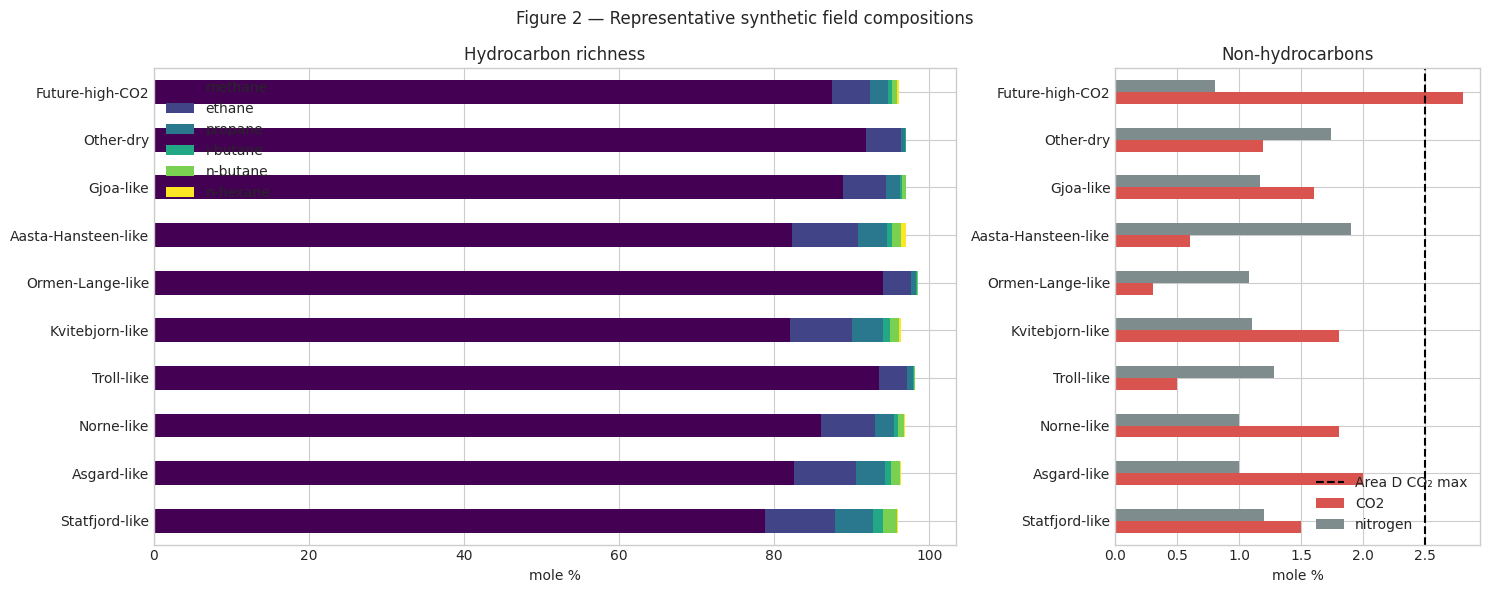

In [8]:
selected_components = [
    "methane",
    "ethane",
    "propane",
    "i-butane",
    "n-butane",
    "n-hexane",
    "CO2",
    "nitrogen",
]
comp_plot = pd.DataFrame(compositions).T[selected_components] * 100
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2.2, 1]})
comp_plot[["methane", "ethane", "propane", "i-butane", "n-butane", "n-hexane"]].plot(
    kind="barh", stacked=True, ax=axes[0], colormap="viridis"
)
axes[0].set_xlabel("mole %")
axes[0].set_title("Hydrocarbon richness")
comp_plot[["CO2", "nitrogen"]].plot(kind="barh", ax=axes[1], color=["#d9534f", "#7f8c8d"])
axes[1].axvline(2.5, color="black", ls="--", lw=1.5, label="Area D CO₂ max")
axes[1].set_xlabel("mole %")
axes[1].set_title("Non-hydrocarbons")
axes[1].legend()
fig.suptitle("Figure 2 — Representative synthetic field compositions")
plt.tight_layout()
plt.show()

In [9]:
fields = pd.DataFrame(
    [
        ("Statfjord-like", "A", "Karsto", 8, 15, 12, False),
        ("Asgard-like", "B", "Karsto", 40, 55, 52, False),
        ("Norne-like", "H", "Karsto", 4, 10, 8, False),
        ("Troll-like", "E", "Kollsnes", 100, 120, 115, False),
        ("Kvitebjorn-like", "G", "Kollsnes", 8, 15, 12, False),
        ("Ormen-Lange-like", "P1", "Nyhamna", 35, 50, 45, False),
        ("Aasta-Hansteen-like", "O1/P2", "Nyhamna", 15, 25, 23, False),
        ("Gjoa-like", "I", "Offshore", 4, 10, 8, False),
        ("Other-dry", "D", "Direct dry", 60, 90, 80, False),
        ("Future-high-CO2", "O1/P2", "Nyhamna", 0, 25, 0, True),
    ],
    columns=[
        "field",
        "area",
        "plant",
        "minimum_MSm3_d",
        "maximum_MSm3_d",
        "reference_MSm3_d",
        "future",
    ],
)
display(fields)
print(
    f"Reference feed slate: {fields.reference_MSm3_d.sum():.1f} MSm3/d "
    "before processing shrinkage"
)

Reference feed slate: 355.0 MSm3/d before processing shrinkage


,field,area,plant,minimum_MSm3_d,maximum_MSm3_d,reference_MSm3_d,future
0,Statfjord-like,A,Karsto,8,15,12,False
1,Asgard-like,B,Karsto,40,55,52,False
2,Norne-like,H,Karsto,4,10,8,False
3,Troll-like,E,Kollsnes,100,120,115,False
4,Kvitebjorn-like,G,Kollsnes,8,15,12,False
5,Ormen-Lange-like,P1,Nyhamna,35,50,45,False
6,Aasta-Hansteen-like,O1/P2,Nyhamna,15,25,23,False
7,Gjoa-like,I,Offshore,4,10,8,False
8,Other-dry,D,Direct dry,60,90,80,False
9,Future-high-CO2,O1/P2,Nyhamna,0,25,0,True


## 5. Reusable NeqSim thermodynamics and quality functions

The SRK equation of state is used consistently. For a mixture:

$$pV = ZnRT.$$

ISO 6976 quality is calculated at the contractual reference conditions. The superior
Wobbe index is:

$$W_s = \frac{H_\mathrm{GCV}}{\sqrt{d_r}}.$$

Hydrocarbon dew-point temperature is flashed at 50 barg for dry-gas handover checks.
Water dew point is flashed independently at 69 barg after adding an assumed trace water
concentration. The Polarled rich-gas check instead interpolates the upper pressure crossing
of the NeqSim phase envelope at 0°C and reports it in barg.

In [10]:
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
STANDARD_PRESSURE_BARA = 1.01325

def build_gas(composition, temperature_c=10.0, pressure_bara=50.0, water_ppmv=None):
    vector = dict(composition)
    if water_ppmv is not None:
        water_fraction = water_ppmv * 1.0e-6
        vector = {k: v * (1.0 - water_fraction) for k, v in vector.items()}
        vector["water"] = water_fraction
    gas = fluid("srk")
    for component, amount in vector.items():
        gas.addComponent(component, float(amount))
    gas.setMixingRule("classic")
    gas.setTemperature(float(temperature_c), "C")
    gas.setPressure(float(pressure_bara), "bara")
    TPflash(gas)
    return gas

def iso6976_quality(composition):
    gas = build_gas(composition, 15.0, 50.0)
    standard = ISO6976(gas.clone())
    standard.setReferenceType("volume")
    standard.setVolRefT(15.0)
    standard.setEnergyRefT(25.0)
    standard.calculate()
    return {
        "GCV_MJ_Sm3": standard.getValue("SuperiorCalorificValue") / 1.0e3,
        "LCV_MJ_Sm3": standard.getValue("InferiorCalorificValue") / 1.0e3,
        "Wobbe_MJ_Sm3": standard.getValue("SuperiorWobbeIndex") / 1.0e3,
        "relative_density": standard.getValue("RelativeDensity"),
    }

def hydrocarbon_dewpoint_c(composition, pressure_barg=50.0):
    pressure_bara = pressure_barg + STANDARD_PRESSURE_BARA
    gas = build_gas(composition, -30.0, pressure_bara)
    ThermodynamicOperations(gas).dewPointTemperatureFlash()
    return gas.getTemperature("C")

def water_dewpoint_c(composition, water_ppmv=12.0, pressure_barg=69.0):
    pressure_bara = pressure_barg + STANDARD_PRESSURE_BARA
    gas = build_gas(composition, -20.0, pressure_bara, water_ppmv=water_ppmv)
    ThermodynamicOperations(gas).waterDewPointTemperatureFlash()
    return gas.getTemperature("C")

def phase_envelope(composition):
    gas = build_gas(composition, -20.0, 10.0)
    ops = ThermodynamicOperations(gas)
    ops.calcPTphaseEnvelope()
    cricondenbar = list(ops.get("cricondenbar"))
    cricondentherm = list(ops.get("cricondentherm"))
    return {
        "dew_T_C": np.asarray(list(ops.get("dewT"))) - 273.15,
        "dew_P_bara": np.asarray(list(ops.get("dewP"))),
        "bubble_T_C": np.asarray(list(ops.get("bubT"))) - 273.15,
        "bubble_P_bara": np.asarray(list(ops.get("bubP"))),
        "cricondenbar_bara": float(cricondenbar[1]),
        "cricondenbar_T_C": float(cricondenbar[0] - 273.15),
        "cricondentherm_C": float(cricondentherm[0] - 273.15),
        "cricondentherm_P_bara": float(cricondentherm[1]),
    }

def hydrocarbon_dewpoint_pressures_barg_at_temperature(envelope, temperature_c):
    dew_temperature_c = envelope["dew_T_C"]
    dew_pressure_bara = envelope["dew_P_bara"]
    finite = np.isfinite(dew_temperature_c) & np.isfinite(dew_pressure_bara)
    dew_temperature_c = dew_temperature_c[finite]
    dew_pressure_bara = dew_pressure_bara[finite]
    crossings_barg = []
    segments = zip(
        dew_temperature_c[:-1],
        dew_temperature_c[1:],
        dew_pressure_bara[:-1],
        dew_pressure_bara[1:],
    )
    for temperature_1, temperature_2, pressure_1, pressure_2 in segments:
        crosses_target = (
            temperature_1 <= temperature_c <= temperature_2
            or temperature_2 <= temperature_c <= temperature_1
        )
        if not crosses_target or temperature_1 == temperature_2:
            continue
        fraction = (temperature_c - temperature_1) / (temperature_2 - temperature_1)
        crossing_bara = pressure_1 + fraction * (pressure_2 - pressure_1)
        crossings_barg.append(float(crossing_bara - STANDARD_PRESSURE_BARA))
    return sorted(crossings_barg)

def upper_hydrocarbon_dewpoint_pressure_barg(envelope, temperature_c=0.0):
    crossings = hydrocarbon_dewpoint_pressures_barg_at_temperature(
        envelope,
        temperature_c,
    )
    if crossings:
        return max(crossings)
    if envelope["cricondentherm_C"] < temperature_c:
        return np.nan
    raise RuntimeError("Phase envelope does not provide the requested dew-point crossing")

def blend_compositions(named_rates):
    total = sum(named_rates.values())
    raw = {}
    for name, rate in named_rates.items():
        for component, fraction in compositions[name].items():
            raw[component] = raw.get(component, 0.0) + rate * fraction
    return {component: amount / total for component, amount in raw.items()}

print("Reusable NeqSim helpers loaded.")

Reusable NeqSim helpers loaded.


## 6. Rich-gas phase envelopes and entry compliance

Cricondenbar is the maximum pressure on the two-phase envelope; cricondentherm is its
maximum temperature. Gassled Areas A, B, and H use those two envelope properties.
Polarled does not: its Operations Manual specifies the maximum **upper hydrocarbon
dew-point pressure at 0°C**. At 0°C, a sufficiently rich gas can intersect the phase
envelope twice; the high-pressure dew-branch crossing is the contractual value checked
against 110 barg.

In [11]:
envelope_names = [
    "Statfjord-like", "Asgard-like", "Norne-like",
    "Kvitebjorn-like", "Aasta-Hansteen-like", "Future-high-CO2",
]
envelopes = {name: phase_envelope(compositions[name]) for name in envelope_names}
envelope_summary = pd.DataFrame(
    {
        name: {
            "cricondenbar_barg": env["cricondenbar_bara"] - STANDARD_PRESSURE_BARA,
            "cricondentherm_C": env["cricondentherm_C"],
            "temperature_at_cricondenbar_C": env["cricondenbar_T_C"],
            "upper_HCDP_barg_at_0C": upper_hydrocarbon_dewpoint_pressure_barg(env),
        }
        for name, env in envelopes.items()
    }
).T
display(envelope_summary.round(2))

aasta_crossings_barg_at_0c = hydrocarbon_dewpoint_pressures_barg_at_temperature(
    envelopes["Aasta-Hansteen-like"],
    0.0,
)
aasta_upper_hcdp_barg_at_0c = max(aasta_crossings_barg_at_0c)
aasta_polarled_margin_barg = 110.0 - aasta_upper_hcdp_barg_at_0c
aasta_c2plus_molpct = 100.0 * sum(
    fraction
    for component, fraction in compositions["Aasta-Hansteen-like"].items()
    if component not in {"methane", "CO2", "nitrogen"}
)
print(f"Aasta-like C2+ content: {aasta_c2plus_molpct:.2f} mol%")
print(f"Aasta-like dew-pressure crossings at 0 C: {aasta_crossings_barg_at_0c}")
print(f"Upper crossing: {aasta_upper_hcdp_barg_at_0c:.2f} barg")
print(f"Margin to Polarled limit: {aasta_polarled_margin_barg:.2f} barg")

Aasta-like C2+ content: 15.15 mol%
Aasta-like dew-pressure crossings at 0 C: [7.225157046556084, 106.28759751834592]
Upper crossing: 106.29 barg
Margin to Polarled limit: 3.71 barg


,cricondenbar_barg,cricondentherm_C,temperature_at_cricondenbar_C,upper_HCDP_barg_at_0C
Statfjord-like,107.99,26.17,-2.23,107.47
Asgard-like,97.62,11.63,-14.04,89.76
Norne-like,88.79,-0.35,-24.70,NaN
Kvitebjorn-like,102.17,18.01,-9.16,98.42
Aasta-Hansteen-like,108.31,25.01,-10.25,106.29
Future-high-CO2,88.91,-1.11,-27.19,NaN


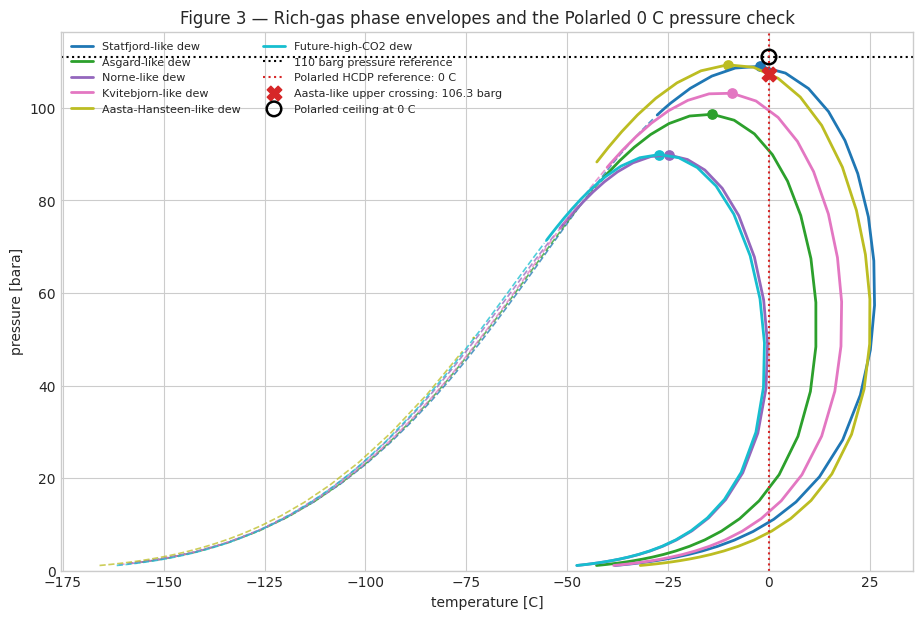

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(envelopes)))
for color, (name, env) in zip(colors, envelopes.items()):
    ax.plot(env["dew_T_C"], env["dew_P_bara"], color=color, lw=2, label=f"{name} dew")
    ax.plot(env["bubble_T_C"], env["bubble_P_bara"], color=color, lw=1.2, ls="--", alpha=0.75)
    ax.scatter(env["cricondenbar_T_C"], env["cricondenbar_bara"], color=color, s=45)
polarled_limit_bara = 110.0 + STANDARD_PRESSURE_BARA
aasta_upper_hcdp_bara = aasta_upper_hcdp_barg_at_0c + STANDARD_PRESSURE_BARA
ax.axhline(
    polarled_limit_bara,
    color="black",
    ls=":",
    label="110 barg pressure reference",
)
ax.axvline(0, color="#d62728", ls=":", label="Polarled HCDP reference: 0 C")
ax.scatter(
    [0],
    [aasta_upper_hcdp_bara],
    color="#d62728",
    marker="X",
    s=110,
    zorder=6,
    label=f"Aasta-like upper crossing: {aasta_upper_hcdp_barg_at_0c:.1f} barg",
)
ax.scatter(
    [0],
    [polarled_limit_bara],
    facecolors="none",
    edgecolors="black",
    s=110,
    linewidths=1.8,
    zorder=6,
    label="Polarled ceiling at 0 C",
)
ax.set_xlabel("temperature [C]")
ax.set_ylabel("pressure [bara]")
ax.set_title("Figure 3 — Rich-gas phase envelopes and the Polarled 0 C pressure check")
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(bottom=0)
plt.show()

In [13]:
def rich_check_row(
    field,
    area,
    basis,
    co2_molpct,
    co2_limit,
    cricondenbar_limit_barg=np.nan,
    cricondentherm_limit_c=np.nan,
    upper_hcdp_limit_barg_at_0c=np.nan,
):
    envelope = envelopes[field]
    return {
        "field": field,
        "area": area,
        "specification_basis": basis,
        "cricondenbar_barg": (
            envelope["cricondenbar_bara"] - STANDARD_PRESSURE_BARA
        ),
        "cricondenbar_limit_barg": cricondenbar_limit_barg,
        "cricondentherm_C": envelope["cricondentherm_C"],
        "cricondentherm_limit_C": cricondentherm_limit_c,
        "upper_HCDP_barg_at_0C": upper_hydrocarbon_dewpoint_pressure_barg(
            envelope,
        ),
        "upper_HCDP_limit_barg_at_0C": upper_hcdp_limit_barg_at_0c,
        "CO2_molpct": co2_molpct,
        "CO2_limit_molpct": co2_limit,
    }

rich_checks = pd.DataFrame(
    [
        rich_check_row("Statfjord-like", "A", "Gassled envelope", 1.5, 2.0, 110, 40),
        rich_check_row("Asgard-like", "B", "Gassled envelope", 2.0, 2.0, 105, 40),
        rich_check_row("Norne-like", "H", "Gassled envelope", 1.8, 2.0, 105, 40),
        rich_check_row(
            "Aasta-Hansteen-like",
            "O1/P2",
            "Polarled upper HCDP pressure at 0 C",
            0.6,
            2.3,
            upper_hcdp_limit_barg_at_0c=110,
        ),
        rich_check_row(
            "Future-high-CO2",
            "O1/P2",
            "Polarled upper HCDP pressure at 0 C",
            2.8,
            2.3,
            upper_hcdp_limit_barg_at_0c=110,
        ),
    ]
)
gassled_rows = rich_checks.specification_basis == "Gassled envelope"
polarled_rows = ~gassled_rows
rich_checks["phase_envelope_pass"] = False
rich_checks.loc[gassled_rows, "phase_envelope_pass"] = (
    (
        rich_checks.loc[gassled_rows, "cricondenbar_barg"]
        <= rich_checks.loc[gassled_rows, "cricondenbar_limit_barg"]
    )
    & (
        rich_checks.loc[gassled_rows, "cricondentherm_C"]
        <= rich_checks.loc[gassled_rows, "cricondentherm_limit_C"]
    )
)
polarled_has_crossing = rich_checks.loc[polarled_rows, "upper_HCDP_barg_at_0C"].notna()
polarled_below_limit = (
    rich_checks.loc[polarled_rows, "upper_HCDP_barg_at_0C"]
    <= rich_checks.loc[polarled_rows, "upper_HCDP_limit_barg_at_0C"]
)
polarled_single_phase = rich_checks.loc[polarled_rows, "cricondentherm_C"] < 0.0
rich_checks.loc[polarled_rows, "phase_envelope_pass"] = (
    (polarled_has_crossing & polarled_below_limit)
    | (~polarled_has_crossing & polarled_single_phase)
)
rich_checks["HCDP_margin_barg_at_0C"] = (
    rich_checks.upper_HCDP_limit_barg_at_0C - rich_checks.upper_HCDP_barg_at_0C
)
rich_checks["CO2_normal_spec_pass"] = (
    rich_checks.CO2_molpct <= rich_checks.CO2_limit_molpct
)
gassled_display = rich_checks.loc[
    gassled_rows,
    [
        "field",
        "area",
        "cricondenbar_barg",
        "cricondenbar_limit_barg",
        "cricondentherm_C",
        "cricondentherm_limit_C",
        "phase_envelope_pass",
    ],
].rename(
    columns={
        "cricondenbar_barg": "ccb_barg",
        "cricondenbar_limit_barg": "ccb_limit",
        "cricondentherm_C": "cct_C",
        "cricondentherm_limit_C": "cct_limit",
        "phase_envelope_pass": "phase_pass",
    }
)
polarled_display = rich_checks.loc[
    polarled_rows,
    [
        "field",
        "area",
        "upper_HCDP_barg_at_0C",
        "upper_HCDP_limit_barg_at_0C",
        "HCDP_margin_barg_at_0C",
        "phase_envelope_pass",
    ],
].rename(
    columns={
        "upper_HCDP_barg_at_0C": "HCDP_barg_at_0C",
        "upper_HCDP_limit_barg_at_0C": "HCDP_limit",
        "HCDP_margin_barg_at_0C": "HCDP_margin",
        "phase_envelope_pass": "phase_pass",
    }
)
co2_display = rich_checks[
    ["field", "area", "CO2_molpct", "CO2_limit_molpct", "CO2_normal_spec_pass"]
].rename(columns={"CO2_normal_spec_pass": "CO2_pass"})
display(gassled_display.round(2))
display(polarled_display.round(2))
display(co2_display.round(2))
print(
    "The richer Aasta-like case passes the Polarled upper HCDP pressure limit at 0 C."
)
print(
    "The synthetic future feed intentionally fails normal Polarled CO2 and needs "
    "booked quality service, removal, blending, or curtailment."
)

The richer Aasta-like case passes the Polarled upper HCDP pressure limit at 0 C.
The synthetic future feed intentionally fails normal Polarled CO2 and needs booked quality service, removal, blending, or curtailment.


,field,area,ccb_barg,ccb_limit,cct_C,cct_limit,phase_pass
0,Statfjord-like,A,107.99,110.0,26.17,40.0,True
1,Asgard-like,B,97.62,105.0,11.63,40.0,True
2,Norne-like,H,88.79,105.0,-0.35,40.0,True


,field,area,HCDP_barg_at_0C,HCDP_limit,HCDP_margin,phase_pass
3,Aasta-Hansteen-like,O1/P2,106.29,110.0,3.71,True
4,Future-high-CO2,O1/P2,NaN,110.0,NaN,True


,field,area,CO2_molpct,CO2_limit_molpct,CO2_pass
0,Statfjord-like,A,1.5,2.0,True
1,Asgard-like,B,2.0,2.0,True
2,Norne-like,H,1.8,2.0,True
3,Aasta-Hansteen-like,O1/P2,0.6,2.3,True
4,Future-high-CO2,O1/P2,2.8,2.3,False


## 7. Onshore processing and assumed NGL recovery

The calculation is a component splitter. If $r_{i,p}$ is the assumed recovery of component
$i$ to NGL at plant $p$, the dry-gas molar yield is:

$$y_p = \sum_i z_i (1-r_{i,p}),$$

and the normalized dry-gas composition is:

$$y_i = \frac{z_i(1-r_{i,p})}{y_p}.$$

These are scenario inputs, not published plant guarantees. Kårstø's public component
product capacities are used later as checks. Kollsnes and Nyhamna feed capacities are
taken from Gassco; the Kårstø total gas-feed limit is an explicit study assumption.

In [14]:
recovery = pd.DataFrame(
    {
        "Karsto": {
            "methane": 0.003,
            "ethane": 0.35,
            "propane": 0.98,
            "i-butane": 0.995,
            "n-butane": 0.995,
            "i-pentane": 0.999,
            "n-pentane": 0.999,
            "n-hexane": 0.9999,
            "CO2": 0.05,
            "nitrogen": 0.0,
        },
        "Kollsnes": {
            "methane": 0.002,
            "ethane": 0.08,
            "propane": 0.90,
            "i-butane": 0.98,
            "n-butane": 0.98,
            "i-pentane": 0.995,
            "n-pentane": 0.995,
            "n-hexane": 0.999,
            "CO2": 0.10,
            "nitrogen": 0.0,
        },
        "Nyhamna": {
            "methane": 0.002,
            "ethane": 0.05,
            "propane": 0.85,
            "i-butane": 0.97,
            "n-butane": 0.97,
            "i-pentane": 0.995,
            "n-pentane": 0.995,
            "n-hexane": 0.999,
            "CO2": 0.10,
            "nitrogen": 0.0,
        },
        "Offshore": {
            "methane": 0.001,
            "ethane": 0.03,
            "propane": 0.80,
            "i-butane": 0.97,
            "n-butane": 0.97,
            "i-pentane": 0.995,
            "n-pentane": 0.995,
            "n-hexane": 0.999,
            "CO2": 0.0,
            "nitrogen": 0.0,
        },
        "Direct dry": {
            "methane": 0.0,
            "ethane": 0.0,
            "propane": 0.0,
            "i-butane": 0.0,
            "n-butane": 0.0,
            "i-pentane": 0.0,
            "n-pentane": 0.0,
            "n-hexane": 0.0,
            "CO2": 0.0,
            "nitrogen": 0.0,
        },
    }
).fillna(0.0)
recovery_display = (100 * recovery).round(2).rename_axis("component")
recovery_display = recovery_display.rename(
    columns=lambda column: f"{column} recovery [%]",
)
display(recovery_display)

,Karsto recovery [%],Kollsnes recovery [%],Nyhamna recovery [%],Offshore recovery [%],Direct dry recovery [%]
component,,,,,
methane,0.30,0.2,0.2,0.1,0.0
ethane,35.00,8.0,5.0,3.0,0.0
propane,98.00,90.0,85.0,80.0,0.0
i-butane,99.50,98.0,97.0,97.0,0.0
n-butane,99.50,98.0,97.0,97.0,0.0
i-pentane,99.90,99.5,99.5,99.5,0.0
n-pentane,99.90,99.5,99.5,99.5,0.0
n-hexane,99.99,99.9,99.9,99.9,0.0
CO2,5.00,10.0,10.0,0.0,0.0


In [15]:
molecular_weight = {
    "methane": 16.043, "ethane": 30.070, "propane": 44.097,
    "i-butane": 58.124, "n-butane": 58.124,
    "i-pentane": 72.151, "n-pentane": 72.151, "n-hexane": 86.178,
    "CO2": 44.010, "nitrogen": 28.014,
}
kmol_per_MSm3 = 1.01325e5 * 1.0e6 / (8.314462618 * 288.15) / 1000.0

def process_one(composition, plant):
    raw_dry = {
        component: fraction * (1.0 - recovery.loc[component, plant])
        for component, fraction in composition.items()
    }
    dry_yield = sum(raw_dry.values())
    dry_composition = {component: amount / dry_yield for component, amount in raw_dry.items()}
    ngl_tonnes_per_MSm3 = {
        component: composition.get(component, 0.0)
        * recovery.loc[component, plant]
        * kmol_per_MSm3
        * molecular_weight[component]
        / 1000.0
        for component in composition
    }
    return raw_dry, dry_yield, dry_composition, ngl_tonnes_per_MSm3

field_models = {}
for row in fields.itertuples(index=False):
    field_models[row.field] = process_one(compositions[row.field], row.plant)

yield_table = pd.DataFrame(
    {
        field: {
            "dry_molar_yield": model[1],
            "NGL_t_per_MSm3_feed": sum(model[3].values()),
            "dry_CO2_molpct": 100 * model[2].get("CO2", 0.0),
        }
        for field, model in field_models.items()
    }
).T
display(yield_table.round(4))

,dry_molar_yield,NGL_t_per_MSm3_feed,dry_CO2_molpct
Statfjord-like,0.8715,254.7388,1.6350
Asgard-like,0.9044,180.6524,2.1009
Norne-like,0.9306,125.7620,1.8376
Troll-like,0.9852,25.9820,0.4567
Kvitebjorn-like,0.9236,162.5077,1.7540
Ormen-Lange-like,0.9877,21.9055,0.2733
Aasta-Hansteen-like,0.9331,147.7583,0.5787
Gjoa-like,0.9733,55.4548,1.6439
Other-dry,1.0000,0.0000,1.1915
Future-high-CO2,0.9568,90.7391,2.6338


In [16]:
reference_rates = fields.set_index("field").reference_MSm3_d.to_dict()
plant_feeds = {}
plant_outputs = {}
plant_ngl = {}
for plant in ["Karsto", "Kollsnes", "Nyhamna", "Offshore", "Direct dry"]:
    members = fields.loc[fields.plant == plant, "field"].tolist()
    rates = {name: reference_rates[name] for name in members if reference_rates[name] > 0}
    total_feed = sum(rates.values())
    if total_feed == 0:
        continue
    raw_dry = {}
    ngl = {}
    for name, rate in rates.items():
        field_raw, _, _, field_ngl = field_models[name]
        for component, amount in field_raw.items():
            raw_dry[component] = raw_dry.get(component, 0.0) + rate * amount
        for component, tonnes_per_rate in field_ngl.items():
            ngl[component] = ngl.get(component, 0.0) + rate * tonnes_per_rate
    dry_rate = sum(raw_dry.values())
    dry_composition = {component: amount / dry_rate for component, amount in raw_dry.items()}
    plant_feeds[plant] = total_feed
    plant_outputs[plant] = (dry_rate, dry_composition)
    plant_ngl[plant] = ngl

plant_balance = pd.DataFrame(
    [
        (
            plant,
            plant_feeds[plant],
            plant_outputs[plant][0],
            plant_feeds[plant] - plant_outputs[plant][0],
            plant_outputs[plant][0] / plant_feeds[plant],
        )
        for plant in plant_feeds
    ],
    columns=[
        "plant",
        "rich_feed_MSm3_d",
        "dry_gas_MSm3_d",
        "molar_shrinkage_MSm3_d",
        "dry_yield",
    ],
)
display(plant_balance.round(3))

,plant,rich_feed_MSm3_d,dry_gas_MSm3_d,molar_shrinkage_MSm3_d,dry_yield
0,Karsto,72,64.931,7.069,0.902
1,Kollsnes,127,124.384,2.616,0.979
2,Nyhamna,68,65.911,2.089,0.969
3,Offshore,8,7.786,0.214,0.973
4,Direct dry,80,80.000,-0.000,1.000


In [17]:
ngl_rows = []
for plant, products in plant_ngl.items():
    grouped = {
        "ethane": products.get("ethane", 0.0),
        "propane": products.get("propane", 0.0),
        "i-butane": products.get("i-butane", 0.0),
        "n-butane": products.get("n-butane", 0.0),
        "naphtha_C5plus": sum(products.get(c, 0.0) for c in ["i-pentane", "n-pentane", "n-hexane"]),
    }
    for product, tonnes_day in grouped.items():
        ngl_rows.append((plant, product, tonnes_day, tonnes_day / 24.0))
ngl_table = pd.DataFrame(ngl_rows, columns=["plant", "product", "tonnes_d", "tonnes_h"])
display(ngl_table.pivot(index="product", columns="plant", values="tonnes_h").fillna(0).round(1))

karsto_public_capacity_t_h = {
    "ethane": 112, "propane": 358, "i-butane": 76,
    "n-butane": 145, "naphtha_C5plus": 106,
}
karsto_check = ngl_table[ngl_table.plant == "Karsto"].copy()
karsto_check["public_capacity_t_h"] = karsto_check["product"].map(karsto_public_capacity_t_h)
karsto_check["utilization_pct"] = 100 * karsto_check.tonnes_h / karsto_check.public_capacity_t_h
display(karsto_check.round(2))
assert (karsto_check.utilization_pct < 100).all()

plant,Direct dry,Karsto,Kollsnes,Nyhamna,Offshore
product,,,,,
ethane,0.0,107.6,22.1,9.6,0.7
i-butane,0.0,61.1,22.4,20.5,2.4
n-butane,0.0,86.0,31.8,31.8,3.6
naphtha_C5plus,0.0,84.3,26.9,41.2,2.7
propane,0.0,211.4,89.9,74.0,9.0


,plant,product,tonnes_d,tonnes_h,public_capacity_t_h,utilization_pct
0,Karsto,ethane,2581.63,107.57,112,96.04
1,Karsto,propane,5073.63,211.40,358,59.05
2,Karsto,i-butane,1467.55,61.15,76,80.46
3,Karsto,n-butane,2064.36,86.01,145,59.32
4,Karsto,naphtha_C5plus,2022.21,84.26,106,79.49


## 8. Quality at each processing and Area D handover point

This calculation adds assumed $12$ ppmv water to processed dry gas. The value is chosen to
demonstrate dehydration control; it is not a measured plant value. Assumed trace
H₂S+COS, O₂, and total sulfur are included in the compliance matrix because the synthetic
hydrocarbon assays do not contain reliable trace contaminants.

In [18]:
quality_rows = []
for plant, (dry_rate, dry_composition) in plant_outputs.items():
    quality = iso6976_quality(dry_composition)
    quality_rows.append(
        {
            "point": f"{plant} dry outlet",
            "dry_rate_MSm3_d": dry_rate,
            "HCDP_C_at_50barg": hydrocarbon_dewpoint_c(dry_composition),
            "WDP_C_at_69barg": water_dewpoint_c(dry_composition, water_ppmv=12.0),
            "CO2_molpct": 100 * dry_composition.get("CO2", 0.0),
            **quality,
            "H2S_COS_mg_Nm3_assumed": 1.0,
            "O2_ppmv_assumed": 0.5,
            "total_sulfur_mg_Nm3_assumed": 5.0,
        }
    )
quality_points = pd.DataFrame(quality_rows).set_index("point")
display(quality_points.round(3))

,dry_rate_MSm3_d,HCDP_C_at_50barg,WDP_C_at_69barg,CO2_molpct,GCV_MJ_Sm3,LCV_MJ_Sm3,Wobbe_MJ_Sm3,relative_density,H2S_COS_mg_Nm3_assumed,O2_ppmv_assumed,total_sulfur_mg_Nm3_assumed
point,,,,,,,,,,,
Karsto dry outlet,64.931,-30.802,-20.694,1.996,38.275,34.548,49.081,0.608,1.0,0.5,5.0
Kollsnes dry outlet,124.384,-30.771,-20.438,0.572,38.207,34.469,49.930,0.586,1.0,0.5,5.0
Nyhamna dry outlet,65.911,-30.974,-20.463,0.373,38.729,34.955,50.317,0.592,1.0,0.5,5.0
Offshore dry outlet,7.786,-30.993,-20.644,1.644,38.464,34.722,49.398,0.606,1.0,0.5,5.0
Direct dry dry outlet,80.000,-33.930,-20.552,1.192,38.386,34.650,49.414,0.603,1.0,0.5,5.0


In [19]:
def area_d_entry_pass(row):
    return pd.Series(
        {
            "HCDP": row.HCDP_C_at_50barg < -10,
            "WDP": row.WDP_C_at_69barg <= -18,
            "CO2": row.CO2_molpct <= 2.5,
            "GCV": 38.1 <= row.GCV_MJ_Sm3 <= 43.7,
            "Wobbe": 48.3 <= row.Wobbe_MJ_Sm3 <= 52.8,
            "H2S_COS": row.H2S_COS_mg_Nm3_assumed <= 5,
            "O2": row.O2_ppmv_assumed <= 2,
            "total_sulfur": row.total_sulfur_mg_Nm3_assumed <= 30,
        }
    )

compliance = quality_points.apply(area_d_entry_pass, axis=1)
compliance["all_normal_Area_D_entry_limits"] = compliance.all(axis=1)
display(compliance)
assert compliance.all().all()

,HCDP,WDP,CO2,GCV,Wobbe,H2S_COS,O2,total_sulfur,all_normal_Area_D_entry_limits
point,,,,,,,,,
Karsto dry outlet,True,True,True,True,True,True,True,True,True
Kollsnes dry outlet,True,True,True,True,True,True,True,True,True
Nyhamna dry outlet,True,True,True,True,True,True,True,True,True
Offshore dry outlet,True,True,True,True,True,True,True,True,True
Direct dry dry outlet,True,True,True,True,True,True,True,True,True


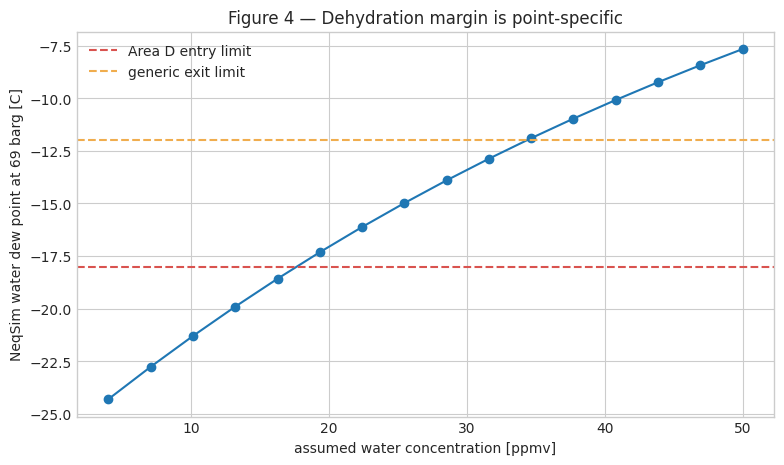

In [20]:
water_grid = np.linspace(4, 50, 16)
reference_dry = plant_outputs["Kollsnes"][1]
water_dp = [water_dewpoint_c(reference_dry, value, 69.0) for value in water_grid]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(water_grid, water_dp, marker="o")
ax.axhline(-18, color="#d9534f", ls="--", label="Area D entry limit")
ax.axhline(-12, color="#f0ad4e", ls="--", label="generic exit limit")
ax.set_xlabel("assumed water concentration [ppmv]")
ax.set_ylabel("NeqSim water dew point at 69 barg [C]")
ax.set_title("Figure 4 — Dehydration margin is point-specific")
ax.legend()
plt.show()

## 9. Rich-gas gathering pipelines with Beggs–Brill

Beggs–Brill is an empirical multiphase correlation. It is useful for a screening study but
does not replace a validated terrain model, seabed-temperature profile, detailed
liquid-loading study, or operator model. All roughness values below are in metres.

In [21]:
def run_beggs_brill(
    name, composition, flow_MSm3_d, inlet_pressure_bara, inlet_temperature_c,
    length_km, diameter_in, increments=16, roughness_m=4.5e-5,
):
    inlet_fluid = build_gas(
        composition,
        inlet_temperature_c,
        inlet_pressure_bara,
    )
    inlet = Stream(f"{name} inlet", inlet_fluid)
    inlet.setFlowRate(float(flow_MSm3_d), "MSm3/day")
    inlet.run()
    pipe = PipeBeggsAndBrills(name, inlet)
    pipe.setLength(float(length_km) * 1000.0)
    pipe.setDiameter(float(diameter_in) * 0.0254)
    pipe.setPipeWallRoughness(float(roughness_m))
    pipe.setNumberOfIncrements(int(increments))
    pipe.setRunIsothermal(True)
    pipe.run()
    return {
        "outlet_pressure_bara": pipe.getOutletPressure(),
        "pressure_drop_bar": pipe.getPressureDrop(),
        "mixture_velocity_m_s": pipe.getMixtureVelocity(),
        "flow_regime": str(pipe.getFlowRegime()),
        "pressure_profile_bara": np.asarray(list(pipe.getPressureProfile())),
    }

rich_pipeline_cases = [
    ("Statpipe rich leg", "Statfjord-like", 12, 167, 20, 228, 28),
    ("Norne Gas Transport", "Norne-like", 8, 245, 10, 128, 16),
    ("Asgard Transport", "Asgard-like", 60, 210, 10, 720, 42),
    ("Kvitebjorn Gas Pipeline", "Kvitebjorn-like", 12, 148, 10, 148, 30),
    ("Gjoa-FLAGS", "Gjoa-like", 8, 154, 10, 131, 28),
    ("Polarled current", "Aasta-Hansteen-like", 23, 210, 5, 482, 36),
    ("Polarled with future", "Future-high-CO2", 38, 210, 5, 482, 36),
    ("Ormen Lange line A", "Ormen-Lange-like", 22.5, 135, 5, 120, 30),
    ("Ormen Lange line B", "Ormen-Lange-like", 22.5, 135, 5, 120, 30),
]

rich_hydraulics = []
rich_profiles = {}
for case in rich_pipeline_cases:
    name, fluid_name, flow_rate, pin, tin, length, diameter = case
    try:
        result = run_beggs_brill(
            name,
            compositions[fluid_name],
            flow_rate,
            pin,
            tin,
            length,
            diameter,
        )
        rich_profiles[name] = result["pressure_profile_bara"]
        rich_hydraulics.append(
            (
                name,
                fluid_name,
                flow_rate,
                pin,
                result["outlet_pressure_bara"],
                result["pressure_drop_bar"],
                result["mixture_velocity_m_s"],
                result["flow_regime"],
                "OK",
            )
        )
    except Exception as exc:
        rich_hydraulics.append(
            (
                name,
                fluid_name,
                flow_rate,
                pin,
                np.nan,
                np.nan,
                np.nan,
                "FAILED",
                str(exc).splitlines()[0][:80],
            )
        )

rich_hydraulics = pd.DataFrame(
    rich_hydraulics,
    columns=[
        "pipeline",
        "fluid",
        "flow_MSm3_d",
        "inlet_bara",
        "outlet_bara",
        "drop_bar",
        "velocity_m_s",
        "regime",
        "status",
    ],
)
hydraulic_columns = [
    "pipeline", "fluid", "flow_MSm3_d", "inlet_bara", "outlet_bara", "drop_bar"
]
regime_columns = ["pipeline", "velocity_m_s", "regime", "status"]
display(rich_hydraulics[hydraulic_columns].round(2))
display(rich_hydraulics[regime_columns].round(2))

,pipeline,fluid,flow_MSm3_d,inlet_bara,outlet_bara,drop_bar
0,Statpipe rich leg,Statfjord-like,12.0,167,158.43,8.57
1,Norne Gas Transport,Norne-like,8.0,245,217.97,27.03
2,Asgard Transport,Asgard-like,60.0,210,139.24,70.76
3,Kvitebjorn Gas Pipeline,Kvitebjorn-like,12.0,148,144.09,3.91
4,Gjoa-FLAGS,Gjoa-like,8.0,154,151.89,2.11
5,Polarled current,Aasta-Hansteen-like,23.0,210,196.35,13.65
6,Polarled with future,Future-high-CO2,38.0,210,172.28,37.72
7,Ormen Lange line A,Ormen-Lange-like,22.5,135,123.26,11.74
8,Ormen Lange line B,Ormen-Lange-like,22.5,135,123.26,11.74


,pipeline,velocity_m_s,regime,status
0,Statpipe rich leg,1.54,SINGLE_PHASE,OK
1,Norne Gas Transport,2.49,SINGLE_PHASE,OK
2,Asgard Transport,3.72,SINGLE_PHASE,OK
3,Kvitebjorn Gas Pipeline,1.40,SINGLE_PHASE,OK
4,Gjoa-FLAGS,1.12,SINGLE_PHASE,OK
5,Polarled current,1.42,SINGLE_PHASE,OK
6,Polarled with future,2.70,SINGLE_PHASE,OK
7,Ormen Lange line A,3.46,SINGLE_PHASE,OK
8,Ormen Lange line B,3.46,SINGLE_PHASE,OK


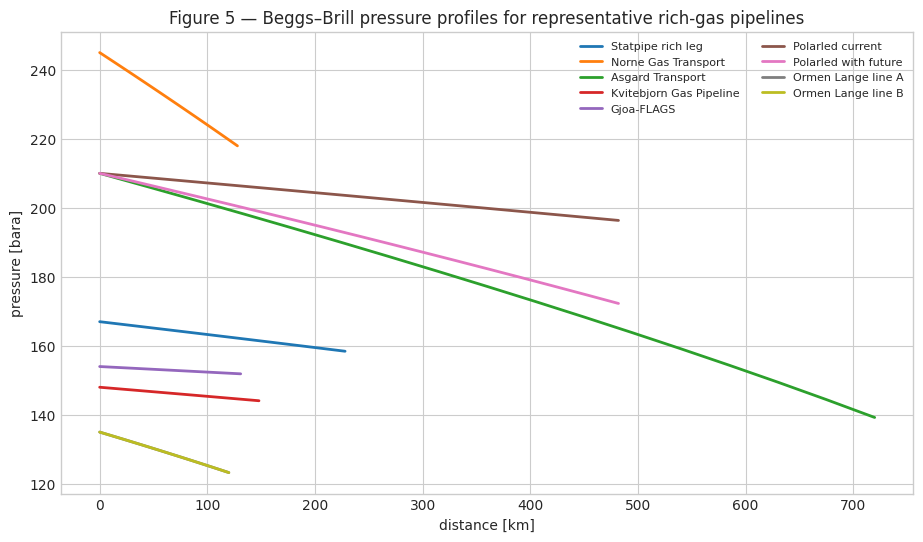

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
for name, profile in rich_profiles.items():
    case_names = [case[0] for case in rich_pipeline_cases]
    length_km = rich_pipeline_cases[case_names.index(name)][5]
    distance = np.linspace(0, length_km, len(profile))
    ax.plot(distance, profile, lw=2, label=name)
ax.set_xlabel("distance [km]")
ax.set_ylabel("pressure [bara]")
ax.set_title("Figure 5 — Beggs–Brill pressure profiles for representative rich-gas pipelines")
ax.legend(fontsize=8, ncol=2)
plt.show()

The two Ormen Lange lines are represented as parallel 30-inch lines carrying half of the
assumed total flow. Their 120 km length is a modelling assumption stated here because it
is not taken from the Gassco transport-map table used for the other geometries.

## 10. Dry-gas export capacity screening

For each export line, a bisection search finds the highest steady rate whose calculated
outlet pressure remains above the contractual minimum:

$$q_\mathrm{cap} = \max_q \left\{q : p_\mathrm{out}(q) \ge p_{\mathrm{exit,min}}\right\}.$$

Inlet pressures are explicit scenario assumptions below, not guaranteed operating
pressures. A $95\%$ operating factor is applied later to retain a modest steady-state
margin.

In [23]:
dry_rate_total = sum(value[0] for value in plant_outputs.values())
pooled_raw = {}
for dry_rate, dry_composition in plant_outputs.values():
    for component, fraction in dry_composition.items():
        pooled_raw[component] = pooled_raw.get(component, 0.0) + dry_rate * fraction
pooled_dry = {component: amount / dry_rate_total for component, amount in pooled_raw.items()}

export_lines = pd.DataFrame(
    [
        ("Europipe I", 667, 40, 170, 84, "Dornum"),
        ("Europipe II", 660, 42, 170, 84, "Dornum"),
        ("Franpipe", 840, 42, 170, 60, "Dunkerque"),
        ("Zeepipe trunk", 808, 40, 170, 80, "Zeebrugge"),
        ("Langeled South", 543, 44, 220, 70, "Easington"),
        ("Norpipe", 440, 36, 140, 49, "Emden"),
        ("Vesterled", 361, 32, 170, 41, "St Fergus"),
    ],
    columns=[
        "pipeline",
        "length_km",
        "diameter_in",
        "assumed_inlet_bara",
        "minimum_exit_barg",
        "terminal",
    ],
)

def outlet_pressure_for_rate(row, rate_MSm3_d):
    try:
        result = run_beggs_brill(
            f"{row.pipeline} capacity",
            pooled_dry,
            rate_MSm3_d,
            row.assumed_inlet_bara,
            10.0,
            row.length_km,
            row.diameter_in,
            increments=12,
        )
        return result["outlet_pressure_bara"]
    except Exception:
        return -1.0e6

def hydraulic_capacity(row, upper=140.0):
    low, high = 0.1, upper
    for _ in range(16):
        mid = 0.5 * (low + high)
        if outlet_pressure_for_rate(row, mid) >= row.minimum_exit_barg:
            low = mid
        else:
            high = mid
    return low

export_lines["BB_capacity_MSm3_d"] = [
    hydraulic_capacity(row)
    for row in export_lines.itertuples(index=False)
]
export_lines["planning_capacity_95pct"] = 0.95 * export_lines.BB_capacity_MSm3_d
export_lines["capacity_GSm3_y"] = export_lines.planning_capacity_95pct * 365 / 1000
export_geometry_columns = [
    "pipeline",
    "length_km",
    "diameter_in",
    "assumed_inlet_bara",
    "minimum_exit_barg",
    "terminal",
]
export_capacity_columns = [
    "pipeline", "BB_capacity_MSm3_d", "planning_capacity_95pct", "capacity_GSm3_y"
]
display(export_lines[export_geometry_columns].round(2))
display(export_lines[export_capacity_columns].round(2))
screened_capacity = export_lines.planning_capacity_95pct.sum()
print(f"Sum of independent 95% corridor screens: {screened_capacity:.1f} MSm3/d")

Sum of independent 95% corridor screens: 397.3 MSm3/d


,pipeline,length_km,diameter_in,assumed_inlet_bara,minimum_exit_barg,terminal
0,Europipe I,667,40,170,84,Dornum
1,Europipe II,660,42,170,84,Dornum
2,Franpipe,840,42,170,60,Dunkerque
3,Zeepipe trunk,808,40,170,80,Zeebrugge
4,Langeled South,543,44,220,70,Easington
5,Norpipe,440,36,140,49,Emden
6,Vesterled,361,32,170,41,St Fergus


,pipeline,BB_capacity_MSm3_d,planning_capacity_95pct,capacity_GSm3_y
0,Europipe I,53.28,50.61,18.47
1,Europipe II,60.77,57.74,21.07
2,Franpipe,58.11,55.21,20.15
3,Zeepipe trunk,49.12,46.67,17.03
4,Langeled South,107.22,101.86,37.18
5,Norpipe,44.05,41.85,15.27
6,Vesterled,45.70,43.41,15.85


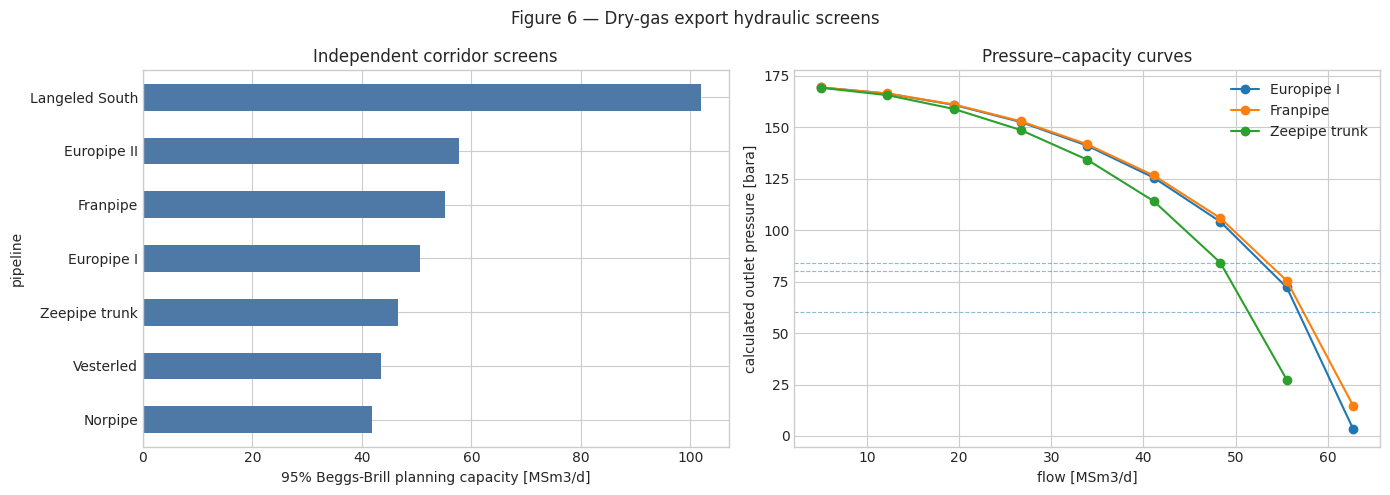

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
export_lines.sort_values("planning_capacity_95pct").plot.barh(
    x="pipeline", y="planning_capacity_95pct", ax=axes[0], color="#4e79a7", legend=False
)
axes[0].set_xlabel("95% Beggs-Brill planning capacity [MSm3/d]")
axes[0].set_title("Independent corridor screens")
rates = np.linspace(5, 70, 10)
for name in ["Europipe I", "Franpipe", "Zeepipe trunk"]:
    row = next(export_lines[export_lines.pipeline == name].itertuples(index=False))
    pressures = [outlet_pressure_for_rate(row, value) for value in rates]
    pressures = [np.nan if value < 0 else value for value in pressures]
    axes[1].plot(rates, pressures, marker="o", label=name)
    axes[1].axhline(row.minimum_exit_barg, ls="--", lw=0.8, alpha=0.5)
axes[1].set_xlabel("flow [MSm3/d]")
axes[1].set_ylabel("calculated outlet pressure [bara]")
axes[1].set_title("Pressure–capacity curves")
axes[1].legend()
fig.suptitle("Figure 6 — Dry-gas export hydraulic screens")
plt.tight_layout()
plt.show()

## 11. NeqSim looped network solver: Kollsnes–Sleipner–Draupner

This explicit loop demonstrates alternative paths:

$$\Delta Q = -\frac{\sum_\ell \Delta p_\ell}{\sum_\ell \left|\partial \Delta p_\ell/\partial Q_\ell\right|}.$$

The network serves 50 MSm³/d to Easington and 30 MSm³/d to Zeebrugge from
Kollsnes D2. It is a worked subnetwork, not a claim that all actual gas follows this route.

**NeqSim 3.16.0 implementation note.** `setPipeModelType(BEGGS_BRILL)` is currently not
consumed for ordinary `addPipe` edges ([issue #2656](https://github.com/equinor/neqsim/issues/2656)).
We therefore use `addMultiphasePipe` per edge. The wrapper also multiplies wall roughness
by 1000 although `PipeBeggsAndBrills` uses metres
([issue #2657](https://github.com/equinor/neqsim/issues/2657)). Until fixed, the network
input uses $4.5\times10^{-8}$ so the internal Beggs–Brill object receives the intended
$4.5\times10^{-5}\,\mathrm{m}$. Standalone capacity calculations above use the correct
metre value directly.

In [25]:
LoopedPipeNetwork = jneqsim.process.equipment.network.LoopedPipeNetwork
conversion_stream = Stream("standard-flow conversion", build_gas(pooled_dry, 10.0, 170.0))
conversion_stream.setFlowRate(1.0, "MSm3/day")
conversion_stream.run()
kg_h_per_MSm3_d = conversion_stream.getFlowRate("kg/hr")

loop_network = LoopedPipeNetwork("Kollsnes-Sleipner-Draupner dry-gas loop")
loop_network.setFluidTemplate(build_gas(pooled_dry, 10.0, 170.0))
loop_network.addSourceNode("Kollsnes D2", 170.0, 80.0 * kg_h_per_MSm3_d)
loop_network.addJunctionNode("Sleipner D7")
loop_network.addJunctionNode("Draupner")
loop_network.addSinkNode("Easington", 50.0 * kg_h_per_MSm3_d)
loop_network.addSinkNode("Zeebrugge", 30.0 * kg_h_per_MSm3_d)

loop_edges = [
    ("Kollsnes D2", "Sleipner D7", "Zeepipe IIA", 299, 40),
    ("Kollsnes D2", "Draupner", "Zeepipe IIB", 300, 40),
    ("Sleipner D7", "Draupner", "Zeepipe interconnector", 39, 40),
    ("Sleipner D7", "Easington", "Langeled South", 543, 44),
    ("Draupner", "Zeebrugge", "Zeepipe trunk", 808, 40),
]
for start, end, name, length_km, diameter_in in loop_edges:
    edge = loop_network.addMultiphasePipe(
        start, end, name, length_km * 1000.0, diameter_in * 0.0254
    )
    edge.setRoughness(4.5e-8)  # version-specific compensation; see issue #2657
    edge.setMultiphaseSegments(8)

loop_network.setTolerance(5000.0)
loop_network.setMaxIterations(50)
loop_network.setRelaxationFactor(0.25)
loop_network.run()

loop_results = pd.DataFrame(
    [
        (
            str(name),
            loop_network.getPipeFlowRate(name) / kg_h_per_MSm3_d,
            loop_network.getPipeHeadLoss(name),
            loop_network.getPipeVelocity(name),
        )
        for name in loop_network.getPipeNames()
    ],
    columns=["pipeline", "flow_MSm3_d", "pressure_drop_bar", "velocity_m_s"],
)
node_results = pd.DataFrame(
    [
        (name, loop_network.getNodePressure(name))
        for name in ["Kollsnes D2", "Sleipner D7", "Draupner", "Easington", "Zeebrugge"]
    ],
    columns=["node", "pressure_bara"],
)
print(f"Converged: {loop_network.isConverged()} in {loop_network.getIterationCount()} iterations")
print(f"Maximum loop residual: {loop_network.getMaxResidual():.1f} Pa")
print(f"Mass-balance error: {loop_network.getMassBalanceError():.3e} kg/s")
display(loop_results.round(3))
display(node_results.round(3))
assert loop_network.isConverged()
assert abs(loop_network.getMassBalanceError()) < 1e-8

Converged: True in 21 iterations
Maximum loop residual: 4502.7 Pa
Mass-balance error: 0.000e+00 kg/s


,pipeline,flow_MSm3_d,pressure_drop_bar,velocity_m_s
0,Zeepipe IIA,40.111,18.194,0.000
1,Zeepipe IIB,39.889,18.048,0.000
2,Zeepipe interconnector,-9.889,-0.159,0.642
3,Langeled South,50.000,37.604,2.685
4,Zeepipe trunk,30.000,32.520,1.949


,node,pressure_bara
0,Kollsnes D2,170.000
1,Sleipner D7,151.800
2,Draupner,151.957
3,Easington,131.714
4,Zeebrugge,133.640


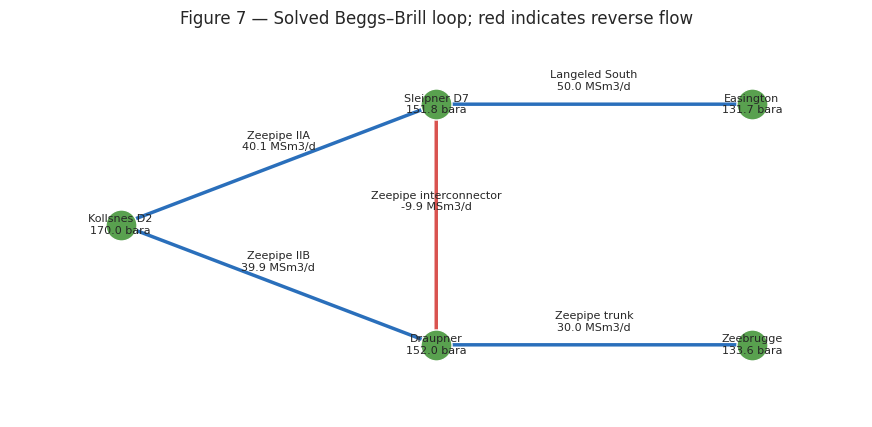

In [26]:
loop_pos = {
    "Kollsnes D2": (0, 1), "Sleipner D7": (2, 2),
    "Draupner": (2, 0), "Easington": (4, 2), "Zeebrugge": (4, 0),
}
fig, ax = plt.subplots(figsize=(11, 5))
for start, end, name, _, _ in loop_edges:
    x1, y1 = loop_pos[start]
    x2, y2 = loop_pos[end]
    flow_value = loop_results.set_index("pipeline").loc[name, "flow_MSm3_d"]
    color = "#d9534f" if flow_value < 0 else "#2a6fbb"
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2.5, color=color),
    )
    ax.text(
        (x1 + x2) / 2,
        (y1 + y2) / 2 + 0.12,
        f"{name}\n{flow_value:.1f} MSm3/d",
        ha="center",
        fontsize=8,
    )
for name, (x, y) in loop_pos.items():
    pressure = node_results.set_index("node").loc[name, "pressure_bara"]
    ax.scatter(x, y, s=500, color="#59a14f", edgecolor="white", zorder=3)
    ax.text(x, y, f"{name}\n{pressure:.1f} bara", ha="center", va="center", fontsize=8)
ax.set_title("Figure 7 — Solved Beggs–Brill loop; red indicates reverse flow")
ax.set_xlim(-0.7, 4.7)
ax.set_ylim(-0.6, 2.6)
ax.axis("off")
plt.show()

## 12. Whole-value-chain optimization

Decision variables are field feed rates $q_i$ and terminal deliveries $x_j$. The
illustrative objective is:

$$\max_{q,x}\left[\sum_i q_i\left(V_{\mathrm{NGL},i}-C_i\right)+\sum_j x_j\left(P_j-C_j\right)\right].$$

Constraints include:

- field min/max rates;
- exact dry-gas target and dry-gas material balance;
- Kårstø, Kollsnes, and Nyhamna feed limits;
- component product limits at Kårstø;
- linear CO₂ blending constraints at each processing hub;
- Beggs–Brill terminal-corridor planning capacities;
- illustrative minimum terminal commitments.

Economics are transparent assumptions in NOK. Published 2026 tariff elements are used
only as anchors; the objective is not a commercial invoice or transport booking.

In [27]:
product_price_NOK_t = {
    "ethane": 4500, "propane": 6500, "i-butane": 6700,
    "n-butane": 6500, "i-pentane": 5600, "n-pentane": 5600,
    "n-hexane": 5400, "methane": 0, "CO2": 0, "nitrogen": 0,
}
field_cost_NOK_Sm3 = {
    "Statfjord-like": 0.42, "Asgard-like": 0.32, "Norne-like": 0.45,
    "Troll-like": 0.20, "Kvitebjorn-like": 0.30,
    "Ormen-Lange-like": 0.29, "Aasta-Hansteen-like": 0.38,
    "Gjoa-like": 0.34, "Other-dry": 0.26, "Future-high-CO2": 0.55,
}
area_tariff_anchor_NOK_Sm3 = {
    "A": 0.0098068, "B": 0.0062407, "G": 0.0026568,
    "I": 0.0072214, "O_Aasta": 0.1604750, "O_Dvalin": 0.1230308,
    "P_Nyhamna": 0.2050513, "D_exit": 0.0126597,
}
terminal_economics = pd.DataFrame(
    [
        ("Europipe I", "Dornum", 3.50, 0.070, 28.0),
        ("Europipe II", "Dornum", 3.50, 0.065, 32.0),
        ("Franpipe", "Dunkerque", 3.52, 0.080, 25.0),
        ("Zeepipe trunk", "Zeebrugge", 3.55, 0.078, 25.0),
        ("Langeled South", "Easington", 3.60, 0.090, 45.0),
        ("Norpipe", "Emden", 3.45, 0.072, 20.0),
        ("Vesterled", "St Fergus", 3.48, 0.075, 18.0),
    ],
    columns=[
        "pipeline",
        "terminal",
        "assumed_price_NOK_Sm3",
        "assumed_route_cost_NOK_Sm3",
        "minimum_commitment_MSm3_d",
    ],
)
terminal_economics = terminal_economics.merge(
    export_lines[["pipeline", "planning_capacity_95pct"]], on="pipeline", how="left"
)
display(terminal_economics.round(4))

,pipeline,terminal,assumed_price_NOK_Sm3,assumed_route_cost_NOK_Sm3,minimum_commitment_MSm3_d,planning_capacity_95pct
0,Europipe I,Dornum,3.50,0.070,28.0,50.6117
1,Europipe II,Dornum,3.50,0.065,32.0,57.7360
2,Franpipe,Dunkerque,3.52,0.080,25.0,55.2091
3,Zeepipe trunk,Zeebrugge,3.55,0.078,25.0,46.6673
4,Langeled South,Easington,3.60,0.090,45.0,101.8565
5,Norpipe,Emden,3.45,0.072,20.0,41.8489
6,Vesterled,St Fergus,3.48,0.075,18.0,43.4145


In [28]:
field_names = fields.field.tolist()
route_names = terminal_economics.pipeline.tolist()
n_field = len(field_names)
n_route = len(route_names)

field_value_mNOK_per_MSm3 = []
for name in field_names:
    ngl_value_NOK = sum(
        field_models[name][3].get(component, 0.0) * product_price_NOK_t.get(component, 0.0)
        for component in field_models[name][3]
    )
    cost_mNOK = field_cost_NOK_Sm3[name]
    field_value_mNOK_per_MSm3.append(ngl_value_NOK / 1.0e6 - cost_mNOK)

route_value_mNOK_per_MSm3 = (
    terminal_economics.assumed_price_NOK_Sm3
    - terminal_economics.assumed_route_cost_NOK_Sm3
    - area_tariff_anchor_NOK_Sm3["D_exit"]
).to_numpy()

plant_capacity = {"Karsto": 88.0, "Kollsnes": 144.5, "Nyhamna": 84.0}
karsto_product_capacity = karsto_public_capacity_t_h

def solve_value_chain(target_MSm3_d, include_future):
    objective = -np.r_[field_value_mNOK_per_MSm3, route_value_mNOK_per_MSm3]
    A_eq = []
    b_eq = []
    dry_yields = np.array([field_models[name][1] for name in field_names])
    A_eq.append(np.r_[dry_yields, -np.ones(n_route)])
    b_eq.append(0.0)
    A_eq.append(np.r_[np.zeros(n_field), np.ones(n_route)])
    b_eq.append(float(target_MSm3_d))

    A_ub = []
    b_ub = []
    indexed_fields = fields.set_index("field")
    for plant, capacity in plant_capacity.items():
        coefficients = np.array(
            [
                1.0 if indexed_fields.loc[name, "plant"] == plant else 0.0
                for name in field_names
            ]
        )
        A_ub.append(np.r_[coefficients, np.zeros(n_route)])
        b_ub.append(capacity)

    # Normal Area D CO2 after each processing plant: sum(CO2 raw) <= 2.5% sum(dry raw).
    for plant in ["Karsto", "Kollsnes", "Nyhamna", "Offshore", "Direct dry"]:
        coefficients = []
        for name in field_names:
            if fields.set_index("field").loc[name, "plant"] == plant:
                raw, dry_yield, _, _ = field_models[name]
                coefficients.append(raw.get("CO2", 0.0) - 0.025 * dry_yield)
            else:
                coefficients.append(0.0)
        A_ub.append(np.r_[coefficients, np.zeros(n_route)])
        b_ub.append(0.0)

    # Public Kårstø product-rate constraints.
    for product, capacity_t_h in karsto_product_capacity.items():
        coefficients = []
        for name in field_names:
            if fields.set_index("field").loc[name, "plant"] != "Karsto":
                coefficients.append(0.0)
                continue
            if product == "naphtha_C5plus":
                c5plus_components = ["i-pentane", "n-pentane", "n-hexane"]
                t_day = sum(
                    field_models[name][3].get(component, 0.0)
                    for component in c5plus_components
                )
            else:
                t_day = field_models[name][3].get(product, 0.0)
            coefficients.append(t_day / 24.0)
        A_ub.append(np.r_[coefficients, np.zeros(n_route)])
        b_ub.append(capacity_t_h)

    bounds = []
    indexed = fields.set_index("field")
    for name in field_names:
        lower = indexed.loc[name, "minimum_MSm3_d"]
        upper = indexed.loc[name, "maximum_MSm3_d"]
        if indexed.loc[name, "future"] and not include_future:
            lower, upper = 0.0, 0.0
        bounds.append((float(lower), float(upper)))
    for row in terminal_economics.itertuples(index=False):
        bounds.append((float(row.minimum_commitment_MSm3_d), float(row.planning_capacity_95pct)))

    result = linprog(
        objective,
        A_ub=np.asarray(A_ub),
        b_ub=np.asarray(b_ub),
        A_eq=np.asarray(A_eq),
        b_eq=np.asarray(b_eq),
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(result.message)
    return result

reported_june_2026 = 10.0 * 1000 / 30.0
reported_2025_average = 121.8 * 1000 / 365.0
base_solution = solve_value_chain(reported_june_2026, include_future=False)
future_solution = solve_value_chain(reported_june_2026, include_future=True)
print(base_solution.message)
print(f"Target: {reported_june_2026:.3f} MSm3/d")

Optimization terminated successfully. (HiGHS Status 7: Optimal)
Target: 333.333 MSm3/d


In [29]:
def unpack_solution(result, scenario):
    field_result = pd.DataFrame(
        {
            "scenario": scenario,
            "field": field_names,
            "feed_MSm3_d": result.x[:n_field],
            "dry_yield": [field_models[name][1] for name in field_names],
        }
    )
    field_result["dry_gas_MSm3_d"] = field_result.feed_MSm3_d * field_result.dry_yield
    route_result = terminal_economics.copy()
    route_result["scenario"] = scenario
    route_result["flow_MSm3_d"] = result.x[n_field:]
    route_result["utilization_pct"] = (
        100 * route_result.flow_MSm3_d / route_result.planning_capacity_95pct
    )
    return field_result, route_result

base_fields, base_routes = unpack_solution(base_solution, "existing fields")
future_fields, future_routes = unpack_solution(future_solution, "future tie-in available")
field_comparison = pd.concat([base_fields, future_fields]).pivot(
    index="field", columns="scenario", values=["feed_MSm3_d", "dry_gas_MSm3_d"]
)
route_comparison = pd.concat([base_routes, future_routes]).pivot(
    index="pipeline", columns="scenario", values=["flow_MSm3_d", "utilization_pct"]
)
display(field_comparison["feed_MSm3_d"].round(3))
display(field_comparison["dry_gas_MSm3_d"].round(3))
display(route_comparison["flow_MSm3_d"].round(2))
display(route_comparison["utilization_pct"].round(2))

scenario,existing fields,future tie-in available
field,,
Aasta-Hansteen-like,25.000,25.000
Asgard-like,55.000,55.000
Future-high-CO2,0.000,24.000
Gjoa-like,10.000,10.000
Kvitebjorn-like,15.000,15.000
Norne-like,4.128,4.128
Ormen-Lange-like,42.050,35.000
Other-dry,60.000,60.000
Statfjord-like,15.000,15.000


scenario,existing fields,future tie-in available
field,,
Aasta-Hansteen-like,23.328,23.328
Asgard-like,49.741,49.741
Future-high-CO2,0.000,22.963
Gjoa-like,9.733,9.733
Kvitebjorn-like,13.854,13.854
Norne-like,3.842,3.842
Ormen-Lange-like,41.535,34.571
Other-dry,60.000,60.000
Statfjord-like,13.073,13.073


scenario,existing fields,future tie-in available
pipeline,,
Europipe I,33.86,33.86
Europipe II,57.74,57.74
Franpipe,55.21,55.21
Langeled South,101.86,101.86
Norpipe,20.00,20.00
Vesterled,18.00,18.00
Zeepipe trunk,46.67,46.67


scenario,existing fields,future tie-in available
pipeline,,
Europipe I,66.91,66.91
Europipe II,100.00,100.00
Franpipe,100.00,100.00
Langeled South,100.00,100.00
Norpipe,47.79,47.79
Vesterled,41.46,41.46
Zeepipe trunk,100.00,100.00


,scenario,illustrative_value_million_NOK_d,increment_vs_base_million_NOK_d
0,existing fields,1201.01,0.00
1,future tie-in available,1202.55,1.55


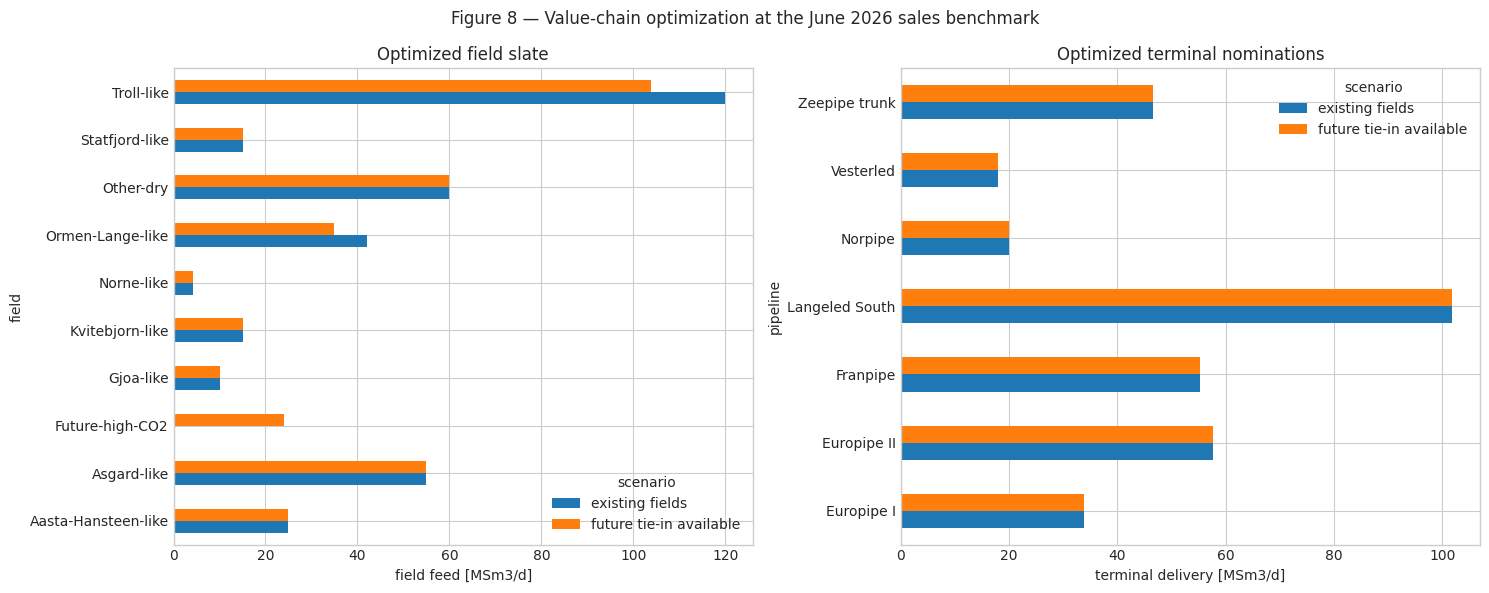

In [30]:
objective_summary = pd.DataFrame(
    [
        ("existing fields", -base_solution.fun),
        ("future tie-in available", -future_solution.fun),
    ],
    columns=["scenario", "illustrative_value_million_NOK_d"],
)
objective_summary["increment_vs_base_million_NOK_d"] = (
    objective_summary.illustrative_value_million_NOK_d
    - objective_summary.illustrative_value_million_NOK_d.iloc[0]
)
display(objective_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
field_plot = pd.concat([base_fields, future_fields]).pivot(
    index="field",
    columns="scenario",
    values="feed_MSm3_d",
)
field_plot.plot.barh(ax=axes[0])
axes[0].set_xlabel("field feed [MSm3/d]")
axes[0].set_title("Optimized field slate")
route_plot = pd.concat([base_routes, future_routes]).pivot(
    index="pipeline",
    columns="scenario",
    values="flow_MSm3_d",
)
route_plot.plot.barh(ax=axes[1])
axes[1].set_xlabel("terminal delivery [MSm3/d]")
axes[1].set_title("Optimized terminal nominations")
fig.suptitle("Figure 8 — Value-chain optimization at the June 2026 sales benchmark")
plt.tight_layout()
plt.show()

In [31]:
def optimized_blend(field_result):
    raw = {}
    for row in field_result.itertuples(index=False):
        field_raw = field_models[row.field][0]
        for component, amount in field_raw.items():
            raw[component] = raw.get(component, 0.0) + row.feed_MSm3_d * amount
    total = sum(raw.values())
    return {component: amount / total for component, amount in raw.items()}, total

optimized_quality_rows = []
optimization_scenarios = [
    ("existing fields", base_fields),
    ("future tie-in available", future_fields),
]
for scenario, result_table in optimization_scenarios:
    blend, rate = optimized_blend(result_table)
    q = iso6976_quality(blend)
    optimized_quality_rows.append(
        {
            "scenario": scenario,
            "dry_rate_MSm3_d": rate,
            "HCDP_C_at_50barg": hydrocarbon_dewpoint_c(blend),
            "WDP_C_at_69barg": water_dewpoint_c(blend, 12.0),
            "CO2_molpct": 100 * blend.get("CO2", 0),
            **q,
        }
    )
optimized_quality = pd.DataFrame(optimized_quality_rows).set_index("scenario")
optimized_quality["Area_D_energy_quality_pass"] = (
    optimized_quality.GCV_MJ_Sm3.between(38.1, 43.7)
    & optimized_quality.Wobbe_MJ_Sm3.between(48.3, 52.8)
    & (optimized_quality.CO2_molpct <= 2.5)
    & (optimized_quality.HCDP_C_at_50barg < -10)
    & (optimized_quality.WDP_C_at_69barg <= -18)
)
dewpoint_columns = [
    "dry_rate_MSm3_d", "WDP_C_at_69barg", "HCDP_C_at_50barg", "CO2_molpct"
]
calorific_columns = [
    "GCV_MJ_Sm3", "Wobbe_MJ_Sm3", "relative_density", "Area_D_energy_quality_pass"
]
display(optimized_quality[dewpoint_columns].round(3))
display(optimized_quality[calorific_columns].round(3))
assert optimized_quality.Area_D_energy_quality_pass.all()

,dry_rate_MSm3_d,WDP_C_at_69barg,HCDP_C_at_50barg,CO2_molpct
scenario,,,,
existing fields,333.333,-20.524,-31.179,0.971
future tie-in available,333.333,-20.549,-31.214,1.125


,GCV_MJ_Sm3,Wobbe_MJ_Sm3,relative_density,Area_D_energy_quality_pass
scenario,,,,
existing fields,38.382,49.724,0.596,True
future tie-in available,38.376,49.630,0.598,True


## 13. Stress tests and operating response

The optimization result is a plan; operators still need margins and response rules.
Three stresses are screened:

1. Nyhamna loses 20 MSm³/d of processing availability.
2. The future high-CO₂ feed attempts to ramp without additional low-CO₂ blending.
3. Export is compared with both the June 2026 and 2025 annual sales benchmarks.

In [32]:
# Nyhamna derating: re-solve by temporarily reducing the plant limit.
original_nyhamna_capacity = plant_capacity["Nyhamna"]
plant_capacity["Nyhamna"] = 64.0
derated_solution = solve_value_chain(reported_june_2026, include_future=True)
derated_fields, derated_routes = unpack_solution(derated_solution, "Nyhamna 64 MSm3/d")
plant_capacity["Nyhamna"] = original_nyhamna_capacity

stress_fields = pd.concat([future_fields, derated_fields]).pivot(
    index="field", columns="scenario", values="feed_MSm3_d"
)
display(stress_fields.round(2))
print(
    "The optimizer replaces derated Nyhamna supply with headroom elsewhere while "
    "maintaining the export target."
)

The optimizer replaces derated Nyhamna supply with headroom elsewhere while maintaining the export target.


scenario,Nyhamna 64 MSm3/d,future tie-in available
field,,
Aasta-Hansteen-like,25.00,25.00
Asgard-like,55.00,55.00
Future-high-CO2,4.00,24.00
Gjoa-like,10.00,10.00
Kvitebjorn-like,15.00,15.00
Norne-like,4.13,4.13
Ormen-Lange-like,35.00,35.00
Other-dry,63.14,60.00
Statfjord-like,15.00,15.00


Normal-spec blend limit under the stated incumbent rates and recovery assumptions: 25.0 MSm3/d


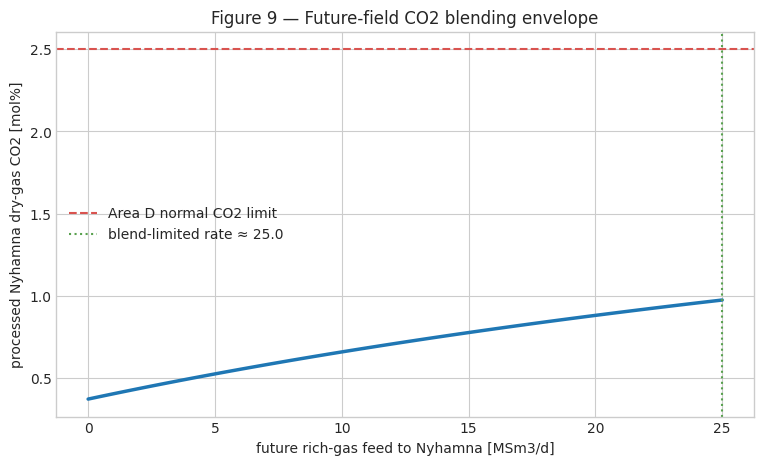

In [33]:
future_name = "Future-high-CO2"
future_raw = field_models[future_name][0]
future_yield = field_models[future_name][1]
nyhamna_incumbents = ["Ormen-Lange-like", "Aasta-Hansteen-like"]

blend_grid = np.linspace(0, 25, 51)
co2_values = []
for future_rate in blend_grid:
    raw = {}
    trial_rates = {
        "Ormen-Lange-like": 45.0,
        "Aasta-Hansteen-like": 23.0,
        future_name: future_rate,
    }
    for name, rate in trial_rates.items():
        for component, amount in field_models[name][0].items():
            raw[component] = raw.get(component, 0.0) + rate * amount
    co2_values.append(100 * raw.get("CO2", 0.0) / sum(raw.values()))
max_normal_future = max(rate for rate, co2 in zip(blend_grid, co2_values) if co2 <= 2.5)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(blend_grid, co2_values, lw=2.5)
ax.axhline(2.5, color="#d9534f", ls="--", label="Area D normal CO2 limit")
ax.axvline(
    max_normal_future,
    color="#59a14f",
    ls=":",
    label=f"blend-limited rate ≈ {max_normal_future:.1f}",
)
ax.set_xlabel("future rich-gas feed to Nyhamna [MSm3/d]")
ax.set_ylabel("processed Nyhamna dry-gas CO2 [mol%]")
ax.set_title("Figure 9 — Future-field CO2 blending envelope")
ax.legend()
plt.show()
print(
    "Normal-spec blend limit under the stated incumbent rates and recovery assumptions: "
    f"{max_normal_future:.1f} MSm3/d"
)

,case,MSm3_d,period_days,basis
0,SODIR June 2026,333.333,30.0,10.0 GSm3 / 30 d
1,SODIR/NPD 2025 average,333.699,365.0,121.8 GSm3 / 365 d
2,optimized existing-fields case,333.333,NaN,LP equality
3,optimized future case,333.333,NaN,LP equality


,case,difference_vs_June_2026_pct
0,SODIR June 2026,0.00
1,SODIR/NPD 2025 average,0.11
2,optimized existing-fields case,-0.00
3,optimized future case,-0.00


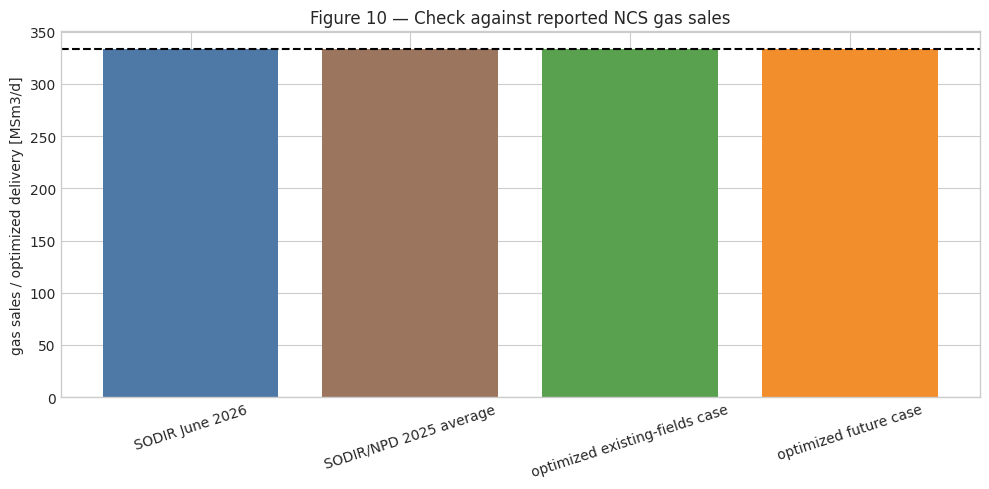

In [34]:
validation = pd.DataFrame(
    [
        ("SODIR June 2026", reported_june_2026, 30, "10.0 GSm3 / 30 d"),
        ("SODIR/NPD 2025 average", reported_2025_average, 365, "121.8 GSm3 / 365 d"),
        ("optimized existing-fields case", base_routes.flow_MSm3_d.sum(), np.nan, "LP equality"),
        ("optimized future case", future_routes.flow_MSm3_d.sum(), np.nan, "LP equality"),
    ],
    columns=["case", "MSm3_d", "period_days", "basis"],
)
validation["difference_vs_June_2026_pct"] = 100 * (validation.MSm3_d / reported_june_2026 - 1)
display(validation[["case", "MSm3_d", "period_days", "basis"]].round(3))
display(validation[["case", "difference_vs_June_2026_pct"]].round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(validation["case"], validation.MSm3_d, color=["#4e79a7", "#9c755f", "#59a14f", "#f28e2b"])
ax.axhline(reported_june_2026, color="black", ls="--")
ax.set_ylabel("gas sales / optimized delivery [MSm3/d]")
ax.set_title("Figure 10 — Check against reported NCS gas sales")
ax.tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

## 14. Operating playbook

### Day-ahead

1. Load field availability, booked entry/processing/quality/exit capacity, maintenance,
   compressor availability, terminal pressure, and measured compositions.
2. Replace the assumed recovery matrix with validated plant performance curves.
3. Run NeqSim quality at every entry and plant outlet. Refuse, remove, blend, or curtail an
   off-spec stream according to the applicable agreement.
4. Optimize field and terminal nominations with explicit headroom.
5. Re-run every selected corridor in a validated hydraulic model and confirm compressor,
   temperature, liquid-holdup, erosional-velocity, and arrival-pressure margins.

### Intraday

1. Track metered energy, inventory/linepack, fuel gas, and operational accounts.
2. Recalculate quality after any field-rate or plant-recovery change.
3. Watch the active constraint: entry CO₂/phase envelope, plant capacity, NGL product
   capacity, terminal pressure, compressor power, or booked capacity.
4. Re-optimize after an outage; use system flexibility only within the applicable Gassco
   terms and operational instruction.

### Future tie-in gate

A high-CO₂ field is admitted only when its incremental value exceeds treatment and
transport cost **and** there is firm processing, quality service, blend-gas, and hydraulic
capacity. The normal-spec blend calculation above is necessary but not sufficient.

## 15. Findings, limitations, and next engineering steps

**Findings from this assumed case**

- Quality must be evaluated at the named contractual point. Rich-gas phase-envelope
  limits, Area D entry dew points, and terminal exit limits are different constraints.
- Polarled Entry O1 from Aasta Hansteen uses an upper hydrocarbon dew-point pressure
  ceiling of 110 barg at 0°C, rather than a cricondenbar/cricondentherm pair. The revised
  synthetic Aasta-like case contains 15.15 mol% C₂+ and its NeqSim SRK upper crossing is
  approximately 106.3 barg, leaving about 3.7 barg margin.
- NeqSim couples composition to phase behavior, energy quality, water dew point, NGL
  yield, density, and pipeline pressure drop in one reproducible workflow.
- The future high-CO₂ feed can be valuable, but its ramp is bounded by Nyhamna capacity
  and CO₂ blending/removal.
- Long export lines are pressure-capacity constraints; summing nameplate or independent
  line screens is not a substitute for a coupled network solve.
- The optimized result exactly matches the June 2026 SODIR average by construction and is
  close to the independently reported 2025 annual average.

**Limitations**

- Synthetic compositions and economics are not confidential/operator data.
- Steady-state Beggs–Brill does not model detailed terrain, slugging, transient linepack,
  hydrate kinetics, corrosion, compressor maps, or control logic.
- Independent export-line bisections ignore upstream shared pressure and compression.
- `LoopedPipeNetwork` limitations in NeqSim 3.16.0 are documented in
  [issue #2656](https://github.com/equinor/neqsim/issues/2656) and
  [issue #2657](https://github.com/equinor/neqsim/issues/2657).
- Contract footnotes and current operations manuals control; this notebook is not a legal
  interpretation of the transportation agreements.

**Next engineering steps**

1. Replace synthetic assays with approved chromatographs and trace-contaminant data.
2. Import compressor maps, terrain, bathymetry, heat-transfer data, and actual equipment
   availability.
3. Add booked-capacity and nomination constraints for each shipper.
4. Calibrate recovery factors and hydraulic roughness to historian data.
5. Extend to multi-period optimization with linepack, maintenance, uncertainty, and
   startup/ramp constraints.

In [35]:
required_outputs = {
    "neqsim_version_pinned": NEQSIM_VERSION == "3.16.0",
    "all_compositions_closed": bool(np.allclose(closure.values, 1.0)),
    "aasta_like_has_rich_C2plus_content": bool(aasta_c2plus_molpct > 10.0),
    "aasta_polarled_HCDP_at_0C_pass": bool(
        aasta_upper_hcdp_barg_at_0c <= 110.0
        and aasta_polarled_margin_barg > 0.0
    ),
    "all_plant_dry_points_pass_normal_Area_D_entry": bool(compliance.all().all()),
    "karsto_public_product_caps_respected": bool((karsto_check.utilization_pct < 100).all()),
    "loop_network_converged": bool(loop_network.isConverged()),
    "loop_mass_balance_closed": bool(abs(loop_network.getMassBalanceError()) < 1e-8),
    "base_optimization_success": bool(base_solution.success),
    "future_optimization_success": bool(future_solution.success),
    "optimized_quality_pass": bool(optimized_quality.Area_D_energy_quality_pass.all()),
    "reported_rate_matched": bool(abs(future_routes.flow_MSm3_d.sum() - reported_june_2026) < 1e-6),
}
final_checks = pd.Series(required_outputs, name="pass")
display(final_checks.to_frame())
assert final_checks.all()
print("All notebook validation checks passed.")

All notebook validation checks passed.


,pass
neqsim_version_pinned,True
all_compositions_closed,True
aasta_like_has_rich_C2plus_content,True
aasta_polarled_HCDP_at_0C_pass,True
all_plant_dry_points_pass_normal_Area_D_entry,True
karsto_public_product_caps_respected,True
loop_network_converged,True
loop_mass_balance_closed,True
base_optimization_success,True
future_optimization_success,True
